# 04. Feature Engineering — 서울 전체 상권 변화 Feature 구축

## 이 노트북의 목적

`01_data_understanding.ipynb` -> `02_preprocessing.ipynb` -> `03_eda.ipynb`를 통해 다음이 이미 확인되었다.

- `data/processed/sales.csv`, `stores.csv`, `population.csv`는 2021Q1~2025Q4(20개 분기)를 서울 전체 상권 기준으로 유지하고 있다.
- `sales`/`stores`의 grain은 `기준_년분기_코드 x 상권_코드 x 서비스_업종_코드`, `population`의 grain은 `기준_년분기_코드 x 상권_코드`이다.
- 황학동 4개 상권(3110055, 3110057, 3130054, 3130055)은 세 데이터 모두에서 20개 분기 전체에 걸쳐 존재한다.
- `03_eda.ipynb`에서 황학동의 핵심 변화 신호(주말 매출 비중 증가, 낮->저녁/야간 소비 이동, 업종 구조 변화(가구 축소·한식음식점/전자상거래업 확대), 매출·점포·유동인구의 방향 불일치, 연령 구성의 매출-유동인구 괴리)가 확인되었고, 다음 단계로 "상권코드 단위로 집계해 서울 전체 상권과 비교할 수 있는 feature 테이블 구성"이 제안되었다.

이번 `04_feature_engineering.ipynb`의 역할은 다음과 같다.

> **서울 전체 상권에 대해 동일한 기준의 상권 변화 Feature를 구축하고, 이후 황학동 진단 · 유사 상권 탐색 · 상권 변화 신호 분석(`05_commercial_signal.ipynb` 이후)에 사용할 분석용 Feature Table을 만드는 것.**

**중요**: 이 단계에서도 처음부터 황학동 4개 상권으로 데이터를 필터링하지 않는다. Feature Table의 기본 단위(grain)는 항상

```
기준_년분기_코드 x 상권_코드
```

이며, 서울 전체 상권을 대상으로 동일한 정의의 feature를 생성한 뒤, 황학 4개 상권 필터링은 오직 섹션 20(Sanity Check)의 결과 확인 목적으로만 사용한다.

## 이번 노트북의 기본 원칙

1. **서울 전체 기준으로 계산**: 평균·표준편차·percentile 등은 항상 서울 전체 상권을 대상으로 계산한다. 황학동 4개 상권만으로 통계를 내지 않는다.
2. **원본 데이터는 수정하지 않는다**: `data/processed/*.csv`를 덮어쓰지 않는다. 모든 feature는 새 DataFrame(`features`)에서 만든다.
3. **결측치를 임의로 0으로 만들지 않는다**: sales/stores/population의 상권 coverage가 완전히 같지 않다는 것이 `02`/`03`에서 이미 확인되었다. 매칭되지 않는 값은 `fillna(0)`으로 채우지 않고 `NaN`으로 유지하며, 대신 `has_sales`/`has_stores`/`has_population`/`complete_case` coverage flag를 만들어 "실제 0"과 "미관측"을 구분한다.
4. **미래 정보 사용 금지**: lag/QoQ/YoY/rolling은 모두 `상권_코드` 기준으로 시간순 정렬 후 `shift()`/trailing `rolling()`만 사용한다. centered rolling은 사용하지 않는다.
5. **상권코드를 key로 사용**: `02`에서 상권코드-상권명 표기 불일치 사례(예: 3110024)가 확인되었으므로, `상권_코드`를 기본 식별자로 사용하고 `상권_코드_명`은 표시용으로만 사용한다.

## 이번 단계에서 만들지 않는 것

`decline_label`, `recovery_label`, `decline_score`, `recovery_score`, `commercial_vitality_score`, `final_risk_score` 등 임의 가중치 기반 종합 점수는 만들지 않는다(예: `0.4*성장률 + 0.3*인구성장률 + ...` 같은 근거 없는 가중합 금지). 이 단계는 **관측 가능한 feature를 설계하는 단계**이며, 쇠퇴/회복 신호 정의는 `05_commercial_signal.ipynb`에서 별도로 다룬다.

또한 이번 단계에서는 LLM/Agent/MCP 등 AI 관련 구성요소를 사용하지 않는다. 재현 가능한 정량 feature를 만드는 것이 목적이며, AI는 이후 상권 변화 신호 -> 유사 상권 탐색 -> 활성화 전략 단계에서 활용한다.

## 해석상 주의

- **상관관계 != 인과관계**: 예) "유동인구 증가 -> 매출 증가"라고 단정하지 않는다.
- **괴리 != 전환 실패**: 예) "유동인구 percentile > 매출 percentile"이라고 해서 "소비 전환율이 낮다"고 표현하지 않는다.
- **성장률 != 회복**, **감소율 != 쇠퇴**: 매출 증감만으로 상권을 "회복" 또는 "쇠퇴"로 판단하지 않는다.

## 1. 라이브러리 및 경로 설정

`02_preprocessing.ipynb`, `03_eda.ipynb`와 동일하게 `notebooks/` 폴더 기준 상대경로(`../data/processed`)로 접근한다.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

PROCESSED_DIR = Path("../data/processed")

SALES_PATH = PROCESSED_DIR / "sales.csv"
STORES_PATH = PROCESSED_DIR / "stores.csv"
POPULATION_PATH = PROCESSED_DIR / "population.csv"

FEATURES_OUT_PATH = PROCESSED_DIR / "commercial_features.csv"
DICTIONARY_OUT_PATH = PROCESSED_DIR / "feature_dictionary.csv"

for name, p in [
    ("SALES_PATH", SALES_PATH), ("STORES_PATH", STORES_PATH), ("POPULATION_PATH", POPULATION_PATH),
]:
    print(f"{name:16s} {p} -> exists: {p.exists()}")

SALES_PATH       ..\data\processed\sales.csv -> exists: True
STORES_PATH      ..\data\processed\stores.csv -> exists: True
POPULATION_PATH  ..\data\processed\population.csv -> exists: True


In [2]:
# 03과 동일한 스타일의 그래프 설정 (한글 폰트는 하드코딩 경로 대신 설치된 폰트 목록에서 탐색)
sns.set_theme(style="whitegrid")

_KOREAN_FONT_CANDIDATES = [
    "Malgun Gothic", "AppleGothic", "NanumGothic", "NanumBarunGothic",
    "Noto Sans CJK KR", "Noto Sans KR", "Gulim",
]
_available_fonts = {f.name for f in fm.fontManager.ttflist}
_font_name = next((c for c in _KOREAN_FONT_CANDIDATES if c in _available_fonts), None)

if _font_name:
    plt.rcParams["font.family"] = _font_name
    print(f"한글 폰트 설정: {_font_name}")
else:
    print("경고: 사용 가능한 한글 폰트를 찾지 못했습니다. 그래프의 한글 라벨이 깨질 수 있습니다.")

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["mathtext.fontset"] = "dejavusans"

import logging
logging.getLogger("matplotlib").setLevel(logging.ERROR)
plt.rcParams["figure.dpi"] = 100

SEOUL_COLOR = "#9E9E9E"
HWANGHAK_COLOR = "#C0392B"
AREA_PALETTE = sns.color_palette("Set2", 4)

한글 폰트 설정: Malgun Gothic


## 2. processed 데이터 로드 및 grain 재확인

`02`/`03`에서 이미 검증된 데이터이므로 전체 품질검사를 반복하지 않고, feature 계산의 전제가 되는 **grain(중복 없음)**과 **기본 커버리지**만 다시 확인한다.

In [3]:
sales = pd.read_csv(SALES_PATH, encoding="utf-8-sig")
stores = pd.read_csv(STORES_PATH, encoding="utf-8-sig")
population = pd.read_csv(POPULATION_PATH, encoding="utf-8-sig")

for label, df in [("sales", sales), ("stores", stores), ("population", population)]:
    print(f"[{label}] shape={df.shape}, 기간={df['기준_년분기_코드'].min()}~{df['기준_년분기_코드'].max()}, "
          f"분기수={df['기준_년분기_코드'].nunique()}, 상권수={df['상권_코드'].nunique()}, "
          f"기준_년분기_코드 dtype={df['기준_년분기_코드'].dtype}, 상권_코드 dtype={df['상권_코드'].dtype}")

[sales] shape=(439141, 55), 기간=20211~20254, 분기수=20, 상권수=1596, 기준_년분기_코드 dtype=int64, 상권_코드 dtype=int64
[stores] shape=(1528872, 14), 기간=20211~20254, 분기수=20, 상권수=1650, 기준_년분기_코드 dtype=int64, 상권_코드 dtype=int64
[population] shape=(32984, 27), 기간=20211~20254, 분기수=20, 상권수=1650, 기준_년분기_코드 dtype=int64, 상권_코드 dtype=int64


In [4]:
def assert_no_dup(df, key_cols, label):
    dup = int(df.duplicated(subset=key_cols).sum())
    print(f"[{label}] grain key {key_cols} 기준 중복: {dup}건")
    assert dup == 0, f"{label}의 grain key에 중복이 있습니다."


assert_no_dup(sales, ["기준_년분기_코드", "상권_코드", "서비스_업종_코드"], "sales")
assert_no_dup(stores, ["기준_년분기_코드", "상권_코드", "서비스_업종_코드"], "stores")
assert_no_dup(population, ["기준_년분기_코드", "상권_코드"], "population")

EXPECTED_QUARTERS = [int(f"{y}{q}") for y in range(2021, 2026) for q in range(1, 5)]
for label, df in [("sales", sales), ("stores", stores), ("population", population)]:
    assert sorted(df["기준_년분기_코드"].unique().tolist()) == EXPECTED_QUARTERS, f"{label}의 분기 범위가 예상과 다릅니다."
print("\n세 데이터 모두 20211~20254 전체 20개 분기 확인 완료.")

[sales] grain key ['기준_년분기_코드', '상권_코드', '서비스_업종_코드'] 기준 중복: 0건
[stores] grain key ['기준_년분기_코드', '상권_코드', '서비스_업종_코드'] 기준 중복: 0건
[population] grain key ['기준_년분기_코드', '상권_코드'] 기준 중복: 0건

세 데이터 모두 20211~20254 전체 20개 분기 확인 완료.


## 3. 공통 유틸리티 함수

- `safe_divide`: 분모가 0 이하이거나 결측이면 `NaN`을 반환한다(0으로 나누어 `inf`가 생기지 않도록 함).
- `to_quarter_label`/`add_quarter_label`: `03`과 동일하게 `20211` -> `2021Q1` 표시용 컬럼을 만든다(분석 key는 그대로 `기준_년분기_코드` 유지).
- `seoul_percentile`: 분기별로 서울 전체 상권 내에서 특정 값보다 작은 상권의 비율(0~100)을 계산한다. `03_eda.ipynb` 섹션 19에서 사용한 정의(`(series < val).mean() * 100`)와 동일한 방식을 `groupby.rank(method="min")`으로 벡터화한 것이다.

In [5]:
def safe_divide(numerator, denominator):
    """분모가 0 이하이거나 결측이면 NaN을 반환하는 나눗셈. inf가 생기지 않도록 한다."""
    numerator = pd.Series(numerator).astype(float)
    denominator = pd.Series(denominator).astype(float)
    result = np.where(denominator.to_numpy() > 0, numerator.to_numpy() / denominator.to_numpy(), np.nan)
    return pd.Series(result, index=numerator.index)


HWANGHAK_CODES = [3110055, 3110057, 3130054, 3130055]
assert pd.api.types.is_integer_dtype(sales["상권_코드"])
print("HWANGHAK_CODES:", HWANGHAK_CODES)


def to_quarter_label(code):
    code = int(code)
    year, q = divmod(code, 10)
    return f"{year}Q{q}"


QUARTER_ORDER = sorted(sales["기준_년분기_코드"].unique().tolist())
QUARTER_LABELS = [to_quarter_label(q) for q in QUARTER_ORDER]
QUARTER_LABEL_MAP = dict(zip(QUARTER_ORDER, QUARTER_LABELS))


def add_quarter_label(df, quarter_col="기준_년분기_코드"):
    out = df.copy()
    out["분기_라벨"] = pd.Categorical(
        out[quarter_col].map(QUARTER_LABEL_MAP), categories=QUARTER_LABELS, ordered=True
    )
    return out


def seoul_percentile(df, value_col, quarter_col="기준_년분기_코드"):
    """분기별 서울 전체 상권 분포 내에서, 값보다 작은 상권의 비율(0~100)을 반환한다.
    NaN 값은 순위 계산에서 자동으로 제외되어 결과도 NaN으로 유지된다."""
    grouped = df.groupby(quarter_col)[value_col]
    rank_min = grouped.rank(method="min")
    counts = grouped.transform("count")
    return (rank_min - 1) / counts * 100


print("safe_divide / to_quarter_label / seoul_percentile 유틸리티 정의 완료")

HWANGHAK_CODES: [3110055, 3110057, 3130054, 3130055]
safe_divide / to_quarter_label / seoul_percentile 유틸리티 정의 완료


## 4. 상권x분기 기본 테이블(scaffold) 생성

Feature Table의 grain은 `기준_년분기_코드 x 상권_코드`다. `sales`/`stores`는 grain이 `분기 x 상권 x 업종`이므로 먼저 상권x분기 수준으로 집계한 뒤에만 population과 결합한다(원본 grain이 다른 DataFrame을 바로 merge하지 않는다).

`03_eda.ipynb` 섹션 15에서 이미 확인했듯, `stores`를 상권x분기로 집계하면 **20개 분기 x 1,650개 상권 = 33,000행의 완전한 격자(dense grid)**가 만들어지는 반면 `sales`(31,415행)와 `population`(32,984행)은 일부 (분기, 상권) 조합이 비어 있다. 따라서 `stores` 집계 결과를 **기본 scaffold(기준 테이블)**로 사용하고, `sales`/`population`을 이후 단계에서 left join한다. `상권_코드_명`/`상권_구분_코드`/`상권_구분_코드_명`과 같은 표시용 컬럼도 이 scaffold(=stores 기준)에서 가져온다.

In [6]:
STORE_COUNT_COLS = ["점포_수", "개업_점포_수", "폐업_점포_수", "프랜차이즈_점포_수"]

stores_agg = stores.groupby(["기준_년분기_코드", "상권_코드"], as_index=False)[STORE_COUNT_COLS].sum()
stores_agg = stores_agg.rename(columns={
    "점포_수": "store_count",
    "개업_점포_수": "opening_store_count",
    "폐업_점포_수": "closing_store_count",
    "프랜차이즈_점포_수": "franchise_store_count",
})

# 상권_코드_명 등은 분기별로 표기가 바뀔 가능성에 대비해 (분기, 상권) 단위로 첫 번째 값을 사용한다.
area_display_cols = (
    stores.drop_duplicates(subset=["기준_년분기_코드", "상권_코드"])
    [["기준_년분기_코드", "상권_코드", "상권_코드_명", "상권_구분_코드", "상권_구분_코드_명"]]
)

base = stores_agg.merge(area_display_cols, on=["기준_년분기_코드", "상권_코드"], how="left")

print("base shape:", base.shape)
print("고유 상권 수:", base["상권_코드"].nunique(), "/ 고유 분기 수:", base["기준_년분기_코드"].nunique())
assert base.shape[0] == base["상권_코드"].nunique() * base["기준_년분기_코드"].nunique(), \
    "base가 완전한 (분기, 상권) 격자가 아닙니다."
assert int(base.duplicated(subset=["기준_년분기_코드", "상권_코드"]).sum()) == 0, "base grain key에 중복이 있습니다."
assert base["상권_코드_명"].isna().sum() == 0, "표시용 상권_코드_명이 매칭되지 않은 행이 있습니다."
print("base가 (분기 x 상권)의 완전한 격자이며 중복이 없음을 확인했습니다.")
base.head(3)

base shape: (33000, 9)
고유 상권 수: 1650 / 고유 분기 수: 20
base가 (분기 x 상권)의 완전한 격자이며 중복이 없음을 확인했습니다.


,기준_년분기_코드,상권_코드,store_count,opening_store_count,closing_store_count,franchise_store_count,상권_코드_명,상권_구분_코드,상권_구분_코드_명
0,20211,3001491,1546,29,46,87,이태원 관광특구,U,관광특구
1,20211,3001492,8588,167,227,560,명동 남대문 북창동 다동 무교동 관광특구,U,관광특구
2,20211,3001493,14876,389,480,255,동대문패션타운 관광특구,U,관광특구


## 5. 매출 Feature

`sales`를 상권x분기 수준으로 집계한다. 이후 섹션(9. 주중/주말, 10. 시간대, 11. 연령 구조)에서도 동일한 집계 결과(`sales_raw`)를 재사용하므로, 필요한 원본 컬럼 합계를 한 번에 계산해 둔다.

- `total_sales` = `당월_매출_금액` 합계
- `total_transactions` = `당월_매출_건수` 합계
- `avg_transaction_value` = `total_sales / total_transactions` (분모 0이면 `NaN`). 이 값은 "객단가"라고 단정하기보다 **건당 평균 매출** 정도로 해석한다.

In [7]:
TIME_AMOUNT_COLS = [
    "시간대_00~06_매출_금액", "시간대_06~11_매출_금액", "시간대_11~14_매출_금액",
    "시간대_14~17_매출_금액", "시간대_17~21_매출_금액", "시간대_21~24_매출_금액",
]
AGE_AMOUNT_MAP = [
    ("연령대_10_매출_금액", "10"), ("연령대_20_매출_금액", "20"), ("연령대_30_매출_금액", "30"),
    ("연령대_40_매출_금액", "40"), ("연령대_50_매출_금액", "50"), ("연령대_60_이상_매출_금액", "60plus"),
]
AGE_AMOUNT_COLS = [c for c, _ in AGE_AMOUNT_MAP]

SALES_RAW_SUM_COLS = ["당월_매출_금액", "당월_매출_건수", "주중_매출_금액", "주말_매출_금액"] + TIME_AMOUNT_COLS + AGE_AMOUNT_COLS

sales_raw = sales.groupby(["기준_년분기_코드", "상권_코드"], as_index=False)[SALES_RAW_SUM_COLS].sum()
print("sales_raw (상권x분기 집계) shape:", sales_raw.shape)
assert int(sales_raw.duplicated(subset=["기준_년분기_코드", "상권_코드"]).sum()) == 0

# 02_preprocessing에서 이미 확인된 대로, 시간대별 합계/주중+주말 합계는 당월_매출_금액과 행 단위로 100% 일치했다.
# 합은 선형연산이므로 상권x분기로 집계해도 이 일치 관계가 그대로 유지되는지 재확인한다.
time_sum_diff = (sales_raw["당월_매출_금액"] - sales_raw[TIME_AMOUNT_COLS].sum(axis=1)).abs().max()
weekday_sum_diff = (sales_raw["당월_매출_금액"] - (sales_raw["주중_매출_금액"] + sales_raw["주말_매출_금액"])).abs().max()
print("집계 후 시간대합 vs 당월매출 최대 절대차이:", time_sum_diff)
print("집계 후 주중+주말 vs 당월매출 최대 절대차이:", weekday_sum_diff)
assert time_sum_diff == 0 and weekday_sum_diff == 0, "집계 후 시간대/주중주말 합계가 당월 매출과 어긋납니다."

sales_raw (상권x분기 집계) shape: (31415, 18)
집계 후 시간대합 vs 당월매출 최대 절대차이: 0
집계 후 주중+주말 vs 당월매출 최대 절대차이: 0


In [8]:
sales_features = sales_raw[["기준_년분기_코드", "상권_코드"]].copy()
sales_features["total_sales"] = sales_raw["당월_매출_금액"]
sales_features["total_transactions"] = sales_raw["당월_매출_건수"]
sales_features["avg_transaction_value"] = safe_divide(sales_raw["당월_매출_금액"], sales_raw["당월_매출_건수"])

print(sales_features[["total_sales", "total_transactions", "avg_transaction_value"]].describe())
sales_features.head(3)

        total_sales  total_transactions  avg_transaction_value
count  3.141500e+04        3.141500e+04           3.141500e+04
mean   1.427869e+10        4.874486e+05           3.958124e+04
std    4.916107e+10        1.176219e+06           1.066276e+05
min    7.629900e+04        3.000000e+00           3.519545e+03
25%    9.999209e+08        3.671200e+04           1.753485e+04
50%    3.355586e+09        1.533790e+05           2.374120e+04
75%    1.012530e+10        4.391225e+05           3.517702e+04
max    1.449616e+12        2.091736e+07           9.000000e+06


,기준_년분기_코드,상권_코드,total_sales,total_transactions,avg_transaction_value
0,20211,3001491,63397627175,2228118,28453.442401
1,20211,3001492,323097368143,9895032,32652.483402
2,20211,3001493,74049892898,2700312,27422.717411


## 6. 점포 Feature

`stores`는 이미 섹션 4에서 상권x분기로 집계했다(`base`의 `store_count`/`opening_store_count`/`closing_store_count`/`franchise_store_count`). 여기서는 이 count 기반 값으로 파생 비율을 계산한다.

- `net_store_change` = `opening_store_count - closing_store_count`
- `franchise_share` = `franchise_store_count / store_count` (분모 0이면 `NaN`)
- `opening_intensity` = `opening_store_count / store_count`, `closing_intensity` = `closing_store_count / store_count`

**주의 (원본 개업률/폐업률에 대해)**: `02_preprocessing.ipynb`에서 원본 `개업_율`이 100을 초과하는 행 14건, `폐업_률`이 100을 초과하는 행이 723건(서울 전체 기준) 확인되었다(공식 산출식 미확인). 따라서 이 원본 비율 컬럼을 그대로 핵심 feature로 사용하지 않는다. 대신 `개업_점포_수`/`폐업_점포_수`/`점포_수`라는 실제 count를 이용해 우리가 직접 정의한 `opening_intensity`/`closing_intensity`를 사용하며, 이 이름들은 공식 "개업률"/"폐업률"이 아니라 **이 프로젝트에서 정의한 파생지표**임을 명확히 한다. 분모(`store_count`, 해당 분기 시점 점포 수 스톡)는 개업/폐업이 이미 반영된 이후의 값일 수 있어, 유사업종점포수 등 다른 기준으로 계산되는 서울시 공식 개업률/폐업률과 정의가 다르다는 한계가 있다.

In [9]:
base["net_store_change"] = base["opening_store_count"] - base["closing_store_count"]
base["franchise_share"] = safe_divide(base["franchise_store_count"], base["store_count"])
base["opening_intensity"] = safe_divide(base["opening_store_count"], base["store_count"])
base["closing_intensity"] = safe_divide(base["closing_store_count"], base["store_count"])

print(base[["store_count", "net_store_change", "franchise_share", "opening_intensity", "closing_intensity"]].describe())

print("\n[참고] 원본 개업_율/폐업_률 100 초과 건수 재확인 (서울 전체, 02 결과와 일관성 확인용)")
print("개업_율 > 100:", int((stores["개업_율"] > 100).sum()), "건 / 폐업_률 > 100:", int((stores["폐업_률"] > 100).sum()), "건")

        store_count  net_store_change  franchise_share  opening_intensity  closing_intensity
count  33000.000000      33000.000000     33000.000000       33000.000000       33000.000000
mean     292.808424          0.190030         0.087314           0.029407           0.029502
std      638.671162          8.462769         0.058116           0.024933           0.025286
min        1.000000       -357.000000         0.000000           0.000000           0.000000
25%       67.000000         -2.000000         0.050909           0.014493           0.016063
50%      142.000000          0.000000         0.080000           0.026616           0.026906
75%      271.000000          2.000000         0.115079           0.039887           0.039077
max    14971.000000        300.000000         0.666667           0.666667           1.000000

[참고] 원본 개업_율/폐업_률 100 초과 건수 재확인 (서울 전체, 02 결과와 일관성 확인용)
개업_율 > 100: 14 건 / 폐업_률 > 100: 723 건


## 7. 유동인구 Feature

`population`은 이미 `기준_년분기_코드 x 상권_코드` grain이므로 불필요하게 다시 합산하지 않는다.

- `floating_population` = `총_유동인구_수`

`02_preprocessing.ipynb`에서 population의 성별/연령대별/시간대별 세부 합계가 `총_유동인구_수`와 완전히 일치하지 않는 행이 존재함이 확인되었다(절대 차이는 작지만 완전 일치 비율은 30~50% 수준). 연령 구조 비율(섹션 11)은 이 특성을 고려해 "연령대별 유동인구 6개 컬럼의 합"을 분모로 사용하고, 시간대/성별 구성비는 이번 단계에서는 만들지 않는다(공식 집계 기준이 확인되지 않은 세부 항목을 추가로 비율화하면 해석 리스크가 커지고, 이후 신호 탐지 단계에서 바로 필요하지도 않기 때문).

In [10]:
population_features = population[["기준_년분기_코드", "상권_코드", "총_유동인구_수"]].rename(
    columns={"총_유동인구_수": "floating_population"}
).copy()

print("population_features shape:", population_features.shape)
assert int(population_features.duplicated(subset=["기준_년분기_코드", "상권_코드"]).sum()) == 0
population_features["floating_population"].describe()

population_features shape: (32984, 3)


count    3.298400e+04
mean     8.231391e+05
std      8.857071e+05
min      4.000000e+00
25%      2.223360e+05
50%      5.593265e+05
75%      1.136040e+06
max      8.816195e+06
Name: floating_population, dtype: float64

## 8. 주중/주말 소비 구조 Feature

`03_eda.ipynb`에서 황학동의 핵심 변화 신호 중 하나로 **주말 매출 비중 증가**가 확인되었다. `주중_매출_금액 + 주말_매출_금액`이 `당월_매출_금액`과 완전히 일치함을 앞서 재확인했으므로, 이를 분모로 사용한다.

- `weekend_sales_share` = `주말_매출_금액 / (주중_매출_금액 + 주말_매출_금액)` (분모 0이면 `NaN`)
- `weekday_sales_share` = `1 - weekend_sales_share`

In [11]:
_weekday_denom = sales_raw["주중_매출_금액"] + sales_raw["주말_매출_금액"]
sales_features["weekend_sales_share"] = safe_divide(sales_raw["주말_매출_금액"], _weekday_denom)
sales_features["weekday_sales_share"] = np.where(
    sales_features["weekend_sales_share"].isna(), np.nan, 1 - sales_features["weekend_sales_share"]
)

sales_features[["weekend_sales_share", "weekday_sales_share"]].describe()

,weekend_sales_share,weekday_sales_share
count,31415.000000,31415.000000
mean,0.244309,0.755691
std,0.090649,0.090649
min,0.000000,0.000000
25%,0.196097,0.705894
50%,0.248215,0.751785
75%,0.294106,0.803903
max,1.000000,1.000000


## 9. 시간대별 소비 구조 Feature

`03_eda.ipynb`에서 낮 시간대(11~17시) 비중 감소, 저녁·야간 시간대(17~24시) 비중 증가가 확인되었다. 앞서 재확인한 대로 시간대별 매출금액 합계는 `당월_매출_금액`과 완전히 일치하므로, **시간대별 매출금액 6개 컬럼의 합**을 분모로 사용한다(`03`과 동일한 시간대 구간 정의를 사용).

- `late_night_sales_share`(00~06시), `morning_sales_share`(06~11시)
- `daytime_sales_share` = (11~14시 + 14~17시) 비중 — `03`에서 사용한 "낮" 정의와 동일
- `evening_night_sales_share` = (17~21시 + 21~24시) 비중 — `03`에서 사용한 "저녁·야간" 정의와 동일, 이번 노트북에서 EDA 결과와 직접 연결되는 핵심 지표

In [12]:
_time_total = sales_raw[TIME_AMOUNT_COLS].sum(axis=1)

sales_features["late_night_sales_share"] = safe_divide(sales_raw["시간대_00~06_매출_금액"], _time_total)
sales_features["morning_sales_share"] = safe_divide(sales_raw["시간대_06~11_매출_금액"], _time_total)
sales_features["daytime_sales_share"] = safe_divide(
    sales_raw["시간대_11~14_매출_금액"] + sales_raw["시간대_14~17_매출_금액"], _time_total
)
sales_features["evening_night_sales_share"] = safe_divide(
    sales_raw["시간대_17~21_매출_금액"] + sales_raw["시간대_21~24_매출_금액"], _time_total
)

_share_sum_check = (
    sales_features["late_night_sales_share"] + sales_features["morning_sales_share"]
    + sales_features["daytime_sales_share"] + sales_features["evening_night_sales_share"]
).dropna()
print("4개 시간대 비중 합의 최소/최대 (1에 가까워야 함):", _share_sum_check.min(), "/", _share_sum_check.max())

sales_features[["late_night_sales_share", "morning_sales_share", "daytime_sales_share", "evening_night_sales_share"]].describe()

4개 시간대 비중 합의 최소/최대 (1에 가까워야 함): 0.9999999999999999 / 1.0000000000000002


,late_night_sales_share,morning_sales_share,daytime_sales_share,evening_night_sales_share
count,31415.000000,31415.000000,31415.000000,31415.000000
mean,0.026732,0.095027,0.474046,0.404195
std,0.037456,0.072330,0.137442,0.146592
min,0.000000,0.000000,0.000000,0.000000
25%,0.002322,0.049051,0.390764,0.320444
50%,0.014076,0.086330,0.473418,0.405447
75%,0.036732,0.123034,0.553138,0.492087
max,0.806669,1.000000,1.000000,1.000000


## 10. 연령 구조 Feature

`03_eda.ipynb`에서 매출 연령구조와 생활인구 연령구조가 서로 다른 방향으로 움직이는 것이 핵심 관찰이었다. `02_preprocessing.ipynb`에서 연령대별 매출/유동인구 합계가 `당월_매출_금액`/`총_유동인구_수`와 정확히 일치하지 않는 문제가 확인되었으므로(sales는 완전 일치 비율 약 41%, population은 30~50%), **공식 집계 정의가 확인되지 않은 상태에서는 연령대 항목 내부의 구성비**를 사용한다. 즉 `연령대별 매출(또는 유동인구) 6개 항목의 합`을 분모로 사용하고, 이를 `당월_매출_금액`/`총_유동인구_수` 대비 비율로 해석하지 않는다.

- 매출: `sales_age_{10,20,30,40,50,60plus}_share`, `sales_age_2030_share`
- 생활인구: `pop_age_{10,20,30,40,50,60plus}_share`, `pop_age_2030_share`
- 괴리(exploratory): `age_2030_gap` = `sales_age_2030_share - pop_age_2030_share`, `age_60plus_gap` = `sales_age_60plus_share - pop_age_60plus_share`. 이 괴리 feature는 매출/유동인구 데이터가 함께 있어야 계산되므로, sales와 population을 병합하는 섹션 13(Feature Table 결합) 직후에 계산한다. 이 값은 "방문 인구 연령 구성과 매출 연령 구성의 차이"를 나타내는 탐색적 지표일 뿐이며 "전환율"이나 인과관계로 해석하지 않는다.

In [13]:
_age_total = sales_raw[AGE_AMOUNT_COLS].sum(axis=1)
for col, bucket in AGE_AMOUNT_MAP:
    sales_features[f"sales_age_{bucket}_share"] = safe_divide(sales_raw[col], _age_total)
sales_features["sales_age_2030_share"] = safe_divide(
    sales_raw["연령대_20_매출_금액"] + sales_raw["연령대_30_매출_금액"], _age_total
)

AGE_POP_MAP = [
    ("연령대_10_유동인구_수", "10"), ("연령대_20_유동인구_수", "20"), ("연령대_30_유동인구_수", "30"),
    ("연령대_40_유동인구_수", "40"), ("연령대_50_유동인구_수", "50"), ("연령대_60_이상_유동인구_수", "60plus"),
]
AGE_POP_COLS = [c for c, _ in AGE_POP_MAP]
_age_pop_total = population[AGE_POP_COLS].sum(axis=1)
for col, bucket in AGE_POP_MAP:
    population_features[f"pop_age_{bucket}_share"] = safe_divide(population[col], _age_pop_total)
population_features["pop_age_2030_share"] = safe_divide(
    population["연령대_20_유동인구_수"] + population["연령대_30_유동인구_수"], _age_pop_total
)

sales_age_cols = [f"sales_age_{b}_share" for _, b in AGE_AMOUNT_MAP] + ["sales_age_2030_share"]
pop_age_cols = [f"pop_age_{b}_share" for _, b in AGE_POP_MAP] + ["pop_age_2030_share"]
print("매출 연령 구성비 합계 범위 (1에 가까워야 함, 2030 composite 제외):",
      sales_features[[c for c in sales_age_cols if c != "sales_age_2030_share"]].sum(axis=1).dropna().agg(["min", "max"]).to_dict())
print("유동인구 연령 구성비 합계 범위:",
      population_features[[c for c in pop_age_cols if c != "pop_age_2030_share"]].sum(axis=1).dropna().agg(["min", "max"]).to_dict())

매출 연령 구성비 합계 범위 (1에 가까워야 함, 2030 composite 제외): {'min': 0.9999999999999998, 'max': 1.0000000000000002}
유동인구 연령 구성비 합계 범위: {'min': 0.9999999999999998, 'max': 1.0000000000000002}


## 11. 업종 구조 Feature

`03_eda.ipynb`에서 황학동은 단순 매출 증감보다 **업종 구조 변화**(가구 비중 약화, 한식음식점/전자상거래업 비중 확대)가 중요했다. 이 절에서 만드는 `furniture_sales_share`/`korean_food_sales_share`/`ecommerce_sales_share`는 서울 전체 데이터에서 통계적으로 자동 선정한 업종이 아니라, **03 EDA에서 확인된 황학동의 업종 구조 변화 패턴을 정량화하기 위해 사전에 지정한 domain-informed feature**다. 즉 데이터를 먼저 보고 결과에 맞춰 사후적으로 고른 것이 아니라, EDA 단계에서 이미 관찰된 패턴(가구 비중 축소, 한식음식점·전자상거래업 비중 확대)에 근거해 미리 선정한 것임을 명확히 한다. 하드코딩하기 전에 실제 `서비스_업종_코드_명`에 해당 업종이 존재하는지 먼저 확인한다.


In [14]:
TARGET_INDUSTRY_NAMES = ["가구", "한식음식점", "전자상거래업"]
existing_names = set(sales["서비스_업종_코드_명"].unique())
missing = [n for n in TARGET_INDUSTRY_NAMES if n not in existing_names]
print("sales의 서비스_업종_코드_명 고유값 수:", len(existing_names))
print("확인 대상 업종:", TARGET_INDUSTRY_NAMES, "/ 존재하지 않는 업종:", missing if missing else "없음")
assert not missing, f"다음 업종명이 실제 데이터에 존재하지 않습니다: {missing}"

sales의 서비스_업종_코드_명 고유값 수: 63
확인 대상 업종: ['가구', '한식음식점', '전자상거래업'] / 존재하지 않는 업종: 없음


업종별 매출 비중과 그로부터 계산되는 집중도(HHI)는 상권x분기x업종 grain에서 먼저 계산한 뒤 상권x분기 단위로 요약한다. `sales`는 이미 `분기 x 상권 x 업종` grain이 유일함이 확인되었으므로 별도의 재집계 없이 그대로 사용한다.

- `furniture_sales_share`(가구), `korean_food_sales_share`(한식음식점), `ecommerce_sales_share`(전자상거래업) — **03 EDA 기반 domain-informed feature**: 해당 업종 매출 / 상권x분기 전체 매출
- `top1_industry_share`, `top3_industry_share`: 매출 비중 상위 1개/3개 업종의 비중 합
- `industry_hhi` = sum(업종별 비중^2) — 업종 매출 집중도(값이 높을수록 특정 업종에 매출이 집중됨을 의미할 뿐, 좋고 나쁨을 판단하는 지표가 아니다)
- `active_industry_count` = 해당 분기에 매출이 0보다 큰 업종 수


In [15]:
GRAIN_KEYS = ["기준_년분기_코드", "상권_코드"]

ind = sales[GRAIN_KEYS + ["서비스_업종_코드_명", "당월_매출_금액"]].copy()
ind = ind.sort_values(GRAIN_KEYS + ["당월_매출_금액"], ascending=[True, True, False]).reset_index(drop=True)

_area_total = ind.groupby(GRAIN_KEYS)["당월_매출_금액"].transform("sum")
ind["_share"] = safe_divide(ind["당월_매출_금액"], _area_total)
ind["_rank_in_area"] = ind.groupby(GRAIN_KEYS).cumcount() + 1

industry_features = ind.groupby(GRAIN_KEYS, as_index=False).agg(
    top1_industry_share=("_share", "max"),
    industry_hhi=("_share", lambda s: float((s ** 2).sum())),
    active_industry_count=("당월_매출_금액", lambda s: int((s > 0).sum())),
)

top3 = (
    ind[ind["_rank_in_area"] <= 3]
    .groupby(GRAIN_KEYS)["_share"].sum()
    .rename("top3_industry_share")
    .reset_index()
)
industry_features = industry_features.merge(top3, on=GRAIN_KEYS, how="left")

area_total_df = ind.groupby(GRAIN_KEYS, as_index=False)["당월_매출_금액"].sum().rename(
    columns={"당월_매출_금액": "_area_total_sales"}
)
industry_features = industry_features.merge(area_total_df, on=GRAIN_KEYS, how="left")

print("industry_features shape:", industry_features.shape)
assert int(industry_features.duplicated(subset=GRAIN_KEYS).sum()) == 0
industry_features[["top1_industry_share", "top3_industry_share", "industry_hhi", "active_industry_count"]].describe()

industry_features shape: (31415, 7)


,top1_industry_share,top3_industry_share,industry_hhi,active_industry_count
count,31415.000000,31415.000000,31415.000000,31415.000000
mean,0.488738,0.768422,0.365632,13.978704
std,0.243149,0.189872,0.261311,11.326460
min,0.089169,0.263801,0.058597,1.000000
25%,0.293975,0.609873,0.166060,5.000000
50%,0.424124,0.784329,0.274703,11.000000
75%,0.643434,0.960387,0.491177,20.000000
max,1.000000,1.000000,1.000000,55.000000


In [16]:
target_wide = (
    ind[ind["서비스_업종_코드_명"].isin(TARGET_INDUSTRY_NAMES)]
    .pivot_table(index=GRAIN_KEYS, columns="서비스_업종_코드_명", values="당월_매출_금액", aggfunc="sum")
    .reindex(columns=TARGET_INDUSTRY_NAMES)
    .reset_index()
    .rename(columns={"가구": "_furniture_amt", "한식음식점": "_korean_food_amt", "전자상거래업": "_ecommerce_amt"})
)

industry_features = industry_features.merge(target_wide, on=GRAIN_KEYS, how="left")

# 아래 fillna(0)은 "전혀 관측되지 않은 (분기,상권)"을 0으로 채우는 것이 아니라, 이미 sales 데이터가 존재하는
# (분기,상권) 안에서 이 3개 업종 중 일부가 그 분기에 매출이 없었던 경우(=실제 0)를 명시적으로 채우는 것이다.
# (분기,상권) 자체가 sales에 없는 경우는 이 merge 이전 단계(ind)에 애초에 포함되지 않으므로 영향받지 않는다.
for c in ["_furniture_amt", "_korean_food_amt", "_ecommerce_amt"]:
    industry_features[c] = industry_features[c].fillna(0.0)

industry_features["furniture_sales_share"] = safe_divide(industry_features["_furniture_amt"], industry_features["_area_total_sales"])
industry_features["korean_food_sales_share"] = safe_divide(industry_features["_korean_food_amt"], industry_features["_area_total_sales"])
industry_features["ecommerce_sales_share"] = safe_divide(industry_features["_ecommerce_amt"], industry_features["_area_total_sales"])

industry_features = industry_features.drop(columns=["_furniture_amt", "_korean_food_amt", "_ecommerce_amt", "_area_total_sales"])

industry_features[["furniture_sales_share", "korean_food_sales_share", "ecommerce_sales_share"]].describe()

,furniture_sales_share,korean_food_sales_share,ecommerce_sales_share
count,31415.000000,31415.000000,31415.000000
mean,0.007515,0.266112,0.003229
std,0.066073,0.251214,0.039847
min,0.000000,0.000000,0.000000
25%,0.000000,0.084118,0.000000
50%,0.000000,0.196187,0.000000
75%,0.000000,0.361738,0.000000
max,1.000000,1.000000,1.000000


## 12. Feature Table 결합

지금까지 만든 조각들을 하나로 합친다.

- `base`: 상권x분기의 완전한 격자(33,000행, `stores` 기준) + 점포 Feature
- `sales_features`: 매출/주중주말/시간대/연령(매출) Feature (31,415행, sales가 존재하는 (분기,상권)만)
- `population_features`: 유동인구/연령(인구) Feature (32,984행)
- `industry_features`: 업종 구조 Feature (sales와 동일한 (분기,상권) 범위)

`base`를 기준(left)으로 나머지를 `left join`하고, merge indicator를 이용해 `has_sales`/`has_population` coverage flag를 만든다. `has_stores`는 `base` 자체가 `stores` 기준이므로 항상 `True`이고, `complete_case`는 세 데이터가 모두 존재하는 행만 `True`다. **매칭되지 않는 값은 `fillna(0)`으로 채우지 않고 `NaN`으로 남긴다.**

In [17]:
features = base.merge(sales_features, on=["기준_년분기_코드", "상권_코드"], how="left", indicator="_ind_sales")
features["has_sales"] = features["_ind_sales"].eq("both")
features = features.drop(columns="_ind_sales")

features = features.merge(population_features, on=["기준_년분기_코드", "상권_코드"], how="left", indicator="_ind_pop")
features["has_population"] = features["_ind_pop"].eq("both")
features = features.drop(columns="_ind_pop")

features = features.merge(industry_features, on=["기준_년분기_코드", "상권_코드"], how="left", indicator="_ind_industry")
# industry_features는 sales_features와 동일한 (분기,상권) 범위에서 만들어졌으므로 커버리지가 일치해야 한다.
assert (features["_ind_industry"].eq("both") == features["has_sales"]).all(), \
    "업종 구조 feature의 커버리지가 has_sales와 불일치합니다."
features = features.drop(columns="_ind_industry")

features["has_stores"] = True
features["complete_case"] = features["has_sales"] & features["has_stores"] & features["has_population"]

print("features shape:", features.shape)
print("has_sales:", features["has_sales"].sum(), "/ has_population:", features["has_population"].sum(),
      "/ complete_case:", features["complete_case"].sum(), "/ 전체:", len(features))

features shape: (33000, 48)
has_sales: 31415 / has_population: 32984 / complete_case: 31399 / 전체: 33000


### 결합 과정 검증

merge로 인해 grain에 중복이 생기지 않았는지, 상권 수·분기 수가 원본과 일치하는지, coverage flag의 매칭률이 `02`/`03`에서 이미 확인한 수치와 일관되는지 확인한다.

In [18]:
assert not features.duplicated(subset=["기준_년분기_코드", "상권_코드"]).any(), "features의 grain key에 중복이 있습니다."
assert features.shape[0] == 33000, f"features 행 수가 예상(33,000)과 다릅니다: {features.shape[0]}"
assert features["상권_코드"].nunique() == 1650
assert features["기준_년분기_코드"].nunique() == 20

print("shape:", features.shape)
print("고유 상권 수:", features["상권_코드"].nunique())
print("고유 분기 수:", features["기준_년분기_코드"].nunique())
print("grain key 중복: 없음 (assert 통과)")

coverage_summary = features[["has_sales", "has_stores", "has_population", "complete_case"]].mean() * 100
print("\n[coverage 매칭률(%)]")
print(coverage_summary.round(2))

# 02_preprocessing / 03_eda에서 확인된 sales 매칭 결측 1,585건, population 매칭 결측 16건과 일관되는지 확인
print("\nhas_sales == False 행 수:", int((~features['has_sales']).sum()), "(02/03에서 확인된 1,585건과 비교)")
print("has_population == False 행 수:", int((~features['has_population']).sum()), "(02/03에서 확인된 16건과 비교)")

shape: (33000, 48)
고유 상권 수: 1650
고유 분기 수: 20
grain key 중복: 없음 (assert 통과)

[coverage 매칭률(%)]
has_sales          95.20
has_stores        100.00
has_population     99.95
complete_case      95.15
dtype: float64

has_sales == False 행 수: 1585 (02/03에서 확인된 1,585건과 비교)
has_population == False 행 수: 16 (02/03에서 확인된 16건과 비교)


In [19]:
na_report = features.isna().mean().sort_values(ascending=False) * 100
na_report = na_report[na_report > 0]
print("결측 비율(%)이 0보다 큰 컬럼 수:", len(na_report), "/", len(features.columns))
na_report.head(15).round(2).to_frame("결측_비율(%)")

결측 비율(%)이 0보다 큰 컬럼 수: 31 / 48


,결측_비율(%)
avg_transaction_value,4.8
total_sales,4.8
total_transactions,4.8
sales_age_2030_share,4.8
sales_age_60plus_share,4.8
sales_age_50_share,4.8
sales_age_40_share,4.8
sales_age_30_share,4.8
sales_age_20_share,4.8
sales_age_10_share,4.8


### 연령 구조 괴리 (섹션 10에서 예고한 gap feature)

`sales_age_2030_share`(매출 연령 구성)와 `pop_age_2030_share`(유동인구 연령 구성)가 이제 한 테이블에 모두 있으므로 괴리를 계산한다. 두 값 중 하나라도 없으면(`has_sales=False` 또는 `has_population=False`) 결과는 자동으로 `NaN`이 된다.

In [20]:
features["age_2030_gap"] = features["sales_age_2030_share"] - features["pop_age_2030_share"]
features["age_60plus_gap"] = features["sales_age_60plus_share"] - features["pop_age_60plus_share"]

features[["age_2030_gap", "age_60plus_gap"]].describe()

,age_2030_gap,age_60plus_gap
count,31399.000000,31399.000000
mean,-0.045107,0.013101
std,0.120000,0.118816
min,-1.000000,-0.671806
25%,-0.113725,-0.059376
50%,-0.048991,-0.004378
75%,0.019689,0.066729
max,0.798802,1.000000


## 13. 시계열 Lag / QoQ / YoY Feature

**미래 정보 사용 금지 원칙**: 모든 시계열 feature는 `상권_코드` 기준으로 `기준_년분기_코드` 오름차순 정렬 후 `groupby("상권_코드").shift(...)`만 사용한다. 이후 모든 시계열 계산 전에 `features`를 정렬해 둔다.

- `*_qoq` = (당분기 - 직전분기) / 직전분기 x 100 (`shift(1)` 기준)
- `*_yoy` = (당분기 - 전년동분기) / 전년동분기 x 100 (`shift(4)` 기준, 분기 데이터이므로 4분기 전과 비교)
- 분모가 0 이하이거나 결측이면 `NaN` (`safe_divide` 사용, `pct_change`의 암묵적 fill을 쓰지 않고 직접 계산하여 0 나눗셈이 `inf`가 되지 않도록 함)
- 대상: `total_sales`, `total_transactions`, `store_count`, `floating_population`

In [21]:
features = features.sort_values(["상권_코드", "기준_년분기_코드"]).reset_index(drop=True)


def add_qoq_yoy(df, value_col):
    g = df.groupby("상권_코드")[value_col]
    prev1 = g.shift(1)
    prev4 = g.shift(4)
    qoq = safe_divide(df[value_col] - prev1, prev1) * 100
    yoy = safe_divide(df[value_col] - prev4, prev4) * 100
    return qoq, yoy


CHANGE_TARGETS = [
    ("total_sales", "sales"),
    ("total_transactions", "transactions"),
    ("store_count", "stores"),
    ("floating_population", "population"),
]

for value_col, prefix in CHANGE_TARGETS:
    qoq, yoy = add_qoq_yoy(features, value_col)
    features[f"{prefix}_qoq"] = qoq
    features[f"{prefix}_yoy"] = yoy

features[[f"{p}_qoq" for _, p in CHANGE_TARGETS] + [f"{p}_yoy" for _, p in CHANGE_TARGETS]].describe()

,sales_qoq,transactions_qoq,stores_qoq,population_qoq,sales_yoy,transactions_yoy,stores_yoy,population_yoy
count,29778.000000,29778.000000,31350.000000,31329.000000,25023.000000,2.502300e+04,26400.000000,26381.000000
mean,7.703659,11.753089,0.077871,-0.049469,14.259988,2.554064e+02,0.393132,0.348884
std,169.776104,605.885865,3.288136,10.943538,221.354951,3.363902e+04,8.579315,31.620850
min,-99.515939,-99.884047,-44.444444,-99.173554,-99.764188,-9.986683e+01,-57.142857,-99.820789
25%,-7.264180,-7.609168,-1.162791,-3.690445,-8.379229,-1.083593e+01,-2.924690,-7.922584
50%,0.506447,-0.707387,0.000000,-0.304884,0.999083,-2.200775e+00,0.000000,-1.333893
75%,9.744960,8.328080,1.197349,3.062793,13.072383,7.875682e+00,3.130581,5.977080
max,22141.699781,93815.789474,166.666667,832.425793,21955.985443,5.288060e+06,466.666667,2333.915212


### Log Growth

매출 등 규모 변수는 상권별 규모 차이가 커서 작은 기준값에서는 percent growth가 과도하게 커질 수 있다. `log1p(당분기) - log1p(전년동분기)` 형태의 log growth를 percent growth와 함께 병행 계산한다(원래의 `*_yoy` 컬럼은 덮어쓰지 않는다). `total_sales`/`store_count`/`floating_population`은 항상 0 이상이므로 `log1p`가 안전하게 정의된다.

In [22]:
def log_growth_yoy(df, value_col):
    g = df.groupby("상권_코드")[value_col]
    prev4 = g.shift(4)
    return np.log1p(df[value_col]) - np.log1p(prev4)


assert (features["total_sales"].dropna() >= 0).all()
assert (features["store_count"].dropna() >= 0).all()
assert (features["floating_population"].dropna() >= 0).all()

features["sales_yoy_log_growth"] = log_growth_yoy(features, "total_sales")
features["population_yoy_log_growth"] = log_growth_yoy(features, "floating_population")
features["stores_yoy_log_growth"] = log_growth_yoy(features, "store_count")

features[["sales_yoy_log_growth", "population_yoy_log_growth", "stores_yoy_log_growth"]].describe()

,sales_yoy_log_growth,population_yoy_log_growth,stores_yoy_log_growth
count,25023.000000,26381.000000,26400.000000
mean,0.014964,-0.017493,0.001181
std,0.402584,0.204773,0.067050
min,-6.049885,-6.101663,-0.816761
25%,-0.087512,-0.082540,-0.029414
50%,0.009941,-0.013429,0.000000
75%,0.122858,0.058053,0.030772
max,5.396165,3.191608,1.504077


### 극단적인 YoY 값 검증

`sales_yoy`/`transactions_yoy`/`population_yoy`에는 수천 %~수백만 % 수준의 매우 큰 값이 존재한다. 이는 계산 오류가 아니라 **전년 동분기 값(분모)이 매우 작은 상권**에서 자연스럽게 나타나는 현상일 수 있다. 극단값이 존재하는 상권을 직접 추출하여 상권코드/상권명/기준분기/현재값/전년동분기값/YoY를 함께 확인함으로써, 계산 오류인지 작은 분모 때문인지를 판단한다.

In [23]:
def inspect_extreme_yoy(df, value_col, yoy_col, top_n=5):
    """yoy_col 기준 상위 top_n건을 추출해 상권/분기/현재값/전년동분기값을 함께 보여준다.
    전년동분기 기준_년분기_코드는 (당분기 - 10)으로 계산된다(예: 20254 -> 20244, YYYY*10+Q 형식이므로
    같은 분기 번호에서 연도만 1 줄어든다). 이는 YoY 계산에 사용한 shift(4)와 동일한 전년동분기를 가리킨다."""
    top = df.nlargest(top_n, yoy_col)[["상권_코드", "상권_코드_명", "기준_년분기_코드", value_col, yoy_col]].copy()
    top["전년동분기_기준_년분기_코드"] = top["기준_년분기_코드"] - 10
    lookup = df.set_index(["상권_코드", "기준_년분기_코드"])[value_col]
    top[f"전년동분기_{value_col}"] = [
        lookup.get((code, q), np.nan) for code, q in zip(top["상권_코드"], top["전년동분기_기준_년분기_코드"])
    ]
    return top[["상권_코드", "상권_코드_명", "기준_년분기_코드", value_col, f"전년동분기_{value_col}", yoy_col]]


print("[sales_yoy 극단값 상위 5건]")
display(inspect_extreme_yoy(features, "total_sales", "sales_yoy"))

print("\n[transactions_yoy 극단값 상위 5건]")
display(inspect_extreme_yoy(features, "total_transactions", "transactions_yoy"))

print("\n[population_yoy 극단값 상위 5건]")
display(inspect_extreme_yoy(features, "floating_population", "population_yoy"))

[sales_yoy 극단값 상위 5건]


,상권_코드,상권_코드_명,기준_년분기_코드,total_sales,전년동분기_total_sales,sales_yoy
12666,3110628,신목동역,20223,60000000.0,272035.0,21955.985443
5788,3110284,정릉북한산국립공원입구,20231,349189079.0,3711713.0,9307.760756
15570,3110773,당산역 13번,20233,71448352.0,806675.0,8757.142220
10344,3110512,연희지하차도,20221,737791023.0,9445678.0,7710.884756
15575,3110773,당산역 13번,20244,48268242.0,621536.0,7665.960781



[transactions_yoy 극단값 상위 5건]


,상권_코드,상권_코드_명,기준_년분기_코드,total_transactions,전년동분기_total_transactions,transactions_yoy
15578,3110773,당산역 13번,20253,264408.0,5.0,5.288060e+06
15579,3110773,당산역 13번,20254,152513.0,26.0,5.864885e+05
15577,3110773,당산역 13번,20252,17844.0,24.0,7.425000e+04
12666,3110628,신목동역,20223,9185.0,39.0,2.345128e+04
10427,3110516,정원여중,20224,893.0,4.0,2.222500e+04



[population_yoy 극단값 상위 5건]


,상권_코드,상권_코드_명,기준_년분기_코드,floating_population,전년동분기_floating_population,population_yoy
19974,3110993,개포지하차도 북측,20243,48800.0,2005.0,2333.915212
19973,3110993,개포지하차도 북측,20242,50318.0,2533.0,1886.498223
19972,3110993,개포지하차도 북측,20241,45549.0,2578.0,1666.834756
19078,3110948,헌인가구단지,20253,184.0,15.0,1126.666667
20157,3111002,한국교통안전공단 강남자동차검사소,20252,48.0,4.0,1100.000000


위 결과에서 확인되듯, YoY가 극단적으로 큰 사례는 대부분 전년 동분기 값이 매우 작은(0에 가까운) 상권에서 발생한다 — 분자의 절대적인 증가폭 자체는 크지 않아도 작은 분모 때문에 비율이 크게 확대되는 것으로, 계산 로직의 오류는 아니다.

전년 동분기 값이 매우 작은 상권에서는 단순 YoY 성장률이 비정상적으로 크게 보일 수 있다. 따라서 raw YoY는 원본 변화율 정보로 유지하되, 이후 상권 변화 신호 산출이나 AI 모델에서는 `*_yoy_log_growth`, `*_yoy_percentile` 등 상대적으로 안정적인 지표를 함께 활용한다.

**04 단계에서는 이를 해결하기 위해 clipping, winsorization, 임의 threshold 적용, 극단값 제거 등으로 원본 `*_yoy` 값을 임의로 수정하지 않는다.** 실제 상권 변화 신호를 산출할 때 극단값을 어떻게 다룰지는 `05_commercial_signal.ipynb`에서 별도로 결정한다.

## 14. Rolling / 변동성 Feature

상권의 단기 변동과 중기 흐름을 구분하기 위해 **과거 4개 분기(당분기 포함, trailing window)** 기준 rolling 통계를 만든다. `pandas`의 기본 `rolling()`은 trailing(현재 시점까지의 과거 데이터만 사용)이므로, `features`가 이미 상권별 시간순으로 정렬되어 있는 한 미래 데이터가 섞이지 않는다. `min_periods=4`로 지정해 앞의 3개 분기는 `NaN`으로 남긴다(값을 임의로 채우지 않음).

- `sales_4q_mean`, `sales_4q_std`, `sales_4q_cv`(=`std/mean`, 평균이 0이면 `NaN`)
- `population_4q_mean`, `store_4q_mean`

feature 수를 과도하게 늘리지 않기 위해, 이후 신호 탐지에 바로 활용 가능한 이 5개만 생성한다.

In [24]:
def rolling_mean_std(df, value_col, window=4):
    g = df.groupby("상권_코드")[value_col]
    mean = g.transform(lambda s: s.rolling(window, min_periods=window).mean())
    std = g.transform(lambda s: s.rolling(window, min_periods=window).std())
    return mean, std


features["sales_4q_mean"], sales_4q_std = rolling_mean_std(features, "total_sales")
features["sales_4q_std"] = sales_4q_std
features["sales_4q_cv"] = safe_divide(features["sales_4q_std"], features["sales_4q_mean"])

features["population_4q_mean"], _ = rolling_mean_std(features, "floating_population")
features["store_4q_mean"], _ = rolling_mean_std(features, "store_count")

# 미래 데이터가 섞이지 않았는지 임의의 한 상권/분기에서 직접 재계산해 대조한다.
_check_area = HWANGHAK_CODES[0]
_check_quarter = 20214  # 2021Q1~Q4 네 분기가 모두 존재하는 첫 시점
_manual = features[
    (features["상권_코드"] == _check_area) & (features["기준_년분기_코드"].between(20211, 20214))
]["total_sales"]
_manual_mean = _manual.mean()
_computed_mean = features.loc[
    (features["상권_코드"] == _check_area) & (features["기준_년분기_코드"] == _check_quarter), "sales_4q_mean"
].iloc[0]
print(f"상권 {_check_area} 2021Q4 sales_4q_mean 직접 검산: 수동계산={_manual_mean:.2f}, 코드계산={_computed_mean:.2f}")
assert abs(_manual_mean - _computed_mean) < 1e-6, "rolling 계산이 과거 4개 분기(2021Q1~Q4)만 사용하지 않은 것으로 보입니다."
print("-> 2021Q4 시점의 4분기 평균이 2021Q1~Q4(과거~현재)만으로 계산되어 미래 데이터가 섞이지 않았음을 확인했습니다.")

상권 3110055 2021Q4 sales_4q_mean 직접 검산: 수동계산=640609445.75, 코드계산=640609445.75
-> 2021Q4 시점의 4분기 평균이 2021Q1~Q4(과거~현재)만으로 계산되어 미래 데이터가 섞이지 않았음을 확인했습니다.


## 15. Decoupling(괴리) Feature

`03_eda.ipynb`의 핵심 발견 중 하나는 **매출·점포·유동인구가 항상 같은 방향으로 움직이지 않는다**는 것이었다(예: 황학동주방가구거리상점가는 유동인구·점포 수가 늘었는데 매출은 감소). 이를 정량화하기 위해 YoY 증감률 차이와 log growth 차이를 함께 만든다. 이 feature들은 **변수 간 변화 방향의 불일치 정도**를 나타낼 뿐이며, "유동인구가 매출로 전환되지 않는다"는 식의 인과적 의미를 부여하지 않는다.

In [25]:
features["sales_population_yoy_gap"] = features["sales_yoy"] - features["population_yoy"]
features["sales_store_yoy_gap"] = features["sales_yoy"] - features["stores_yoy"]
features["sales_population_log_growth_gap"] = features["sales_yoy_log_growth"] - features["population_yoy_log_growth"]
features["sales_store_log_growth_gap"] = features["sales_yoy_log_growth"] - features["stores_yoy_log_growth"]

features[[
    "sales_population_yoy_gap", "sales_store_yoy_gap",
    "sales_population_log_growth_gap", "sales_store_log_growth_gap",
]].describe()

,sales_population_yoy_gap,sales_store_yoy_gap,sales_population_log_growth_gap,sales_store_log_growth_gap
count,25004.000000,25023.000000,25004.000000,25023.000000
mean,14.259945,13.947391,0.031488,0.013476
std,221.785604,221.255397,0.437349,0.398352
min,-1107.191646,-142.510217,-6.273545,-6.027413
25%,-10.617102,-8.486260,-0.108175,-0.088415
50%,2.382580,1.159553,0.023994,0.011561
75%,17.137617,12.692769,0.168994,0.120093
max,21960.194493,21955.985443,6.034889,5.396165


## 16. 서울 전체 내 상대적 위치 (Percentile) / Benchmark Feature

`03_eda.ipynb` 섹션 19와 동일한 정의(분기별 서울 전체 상권 분포 내에서 값보다 작은 상권의 비율, 0~100)로 수준(level) percentile을 계산하고, 이를 이용한 괴리 feature를 만든다.

In [26]:
features["sales_percentile"] = seoul_percentile(features, "total_sales")
features["store_percentile"] = seoul_percentile(features, "store_count")
features["population_percentile"] = seoul_percentile(features, "floating_population")

features["sales_population_percentile_gap"] = features["sales_percentile"] - features["population_percentile"]
features["sales_store_percentile_gap"] = features["sales_percentile"] - features["store_percentile"]

features[["sales_percentile", "store_percentile", "population_percentile"]].describe()

,sales_percentile,store_percentile,population_percentile
count,31415.000000,33000.000000,32984.000000
mean,49.968160,49.844876,49.969614
std,28.867981,28.937839,28.868026
min,0.000000,0.000000,0.000000
25%,24.968153,24.787879,24.969697
50%,49.968173,49.818182,49.969679
75%,74.968153,74.909091,74.969697
max,99.936468,99.939394,99.939394


추가로 "같은 시기 서울의 다른 상권과 비교했을 때 상대적으로 어떻게 변화했는가"를 보기 위해, YoY 증감률과 소비 시간 구조(주말/저녁야간 비중) 자체를 분기별로 percentile화한 benchmark feature를 만든다. 평균/표준편차 기반 z-score는 극단값의 영향을 받기 쉬우므로, percentile을 우선 사용한다.

In [27]:
features["sales_yoy_percentile"] = seoul_percentile(features, "sales_yoy")
features["population_yoy_percentile"] = seoul_percentile(features, "population_yoy")
features["stores_yoy_percentile"] = seoul_percentile(features, "stores_yoy")
features["weekend_share_percentile"] = seoul_percentile(features, "weekend_sales_share")
features["evening_share_percentile"] = seoul_percentile(features, "evening_night_sales_share")

features[[
    "sales_yoy_percentile", "population_yoy_percentile", "stores_yoy_percentile",
    "weekend_share_percentile", "evening_share_percentile",
]].describe()

,sales_yoy_percentile,population_yoy_percentile,stores_yoy_percentile,weekend_share_percentile,evening_share_percentile
count,25023.000000,26381.000000,26400.000000,31415.000000,31415.000000
mean,49.967973,49.969602,49.585370,49.966274,49.967289
std,28.868099,28.868080,28.891316,28.871224,28.869456
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,24.983985,24.984839,24.606061,24.968153,24.968153
50%,49.968010,49.969679,49.393939,49.968173,49.968173
75%,74.952138,74.954518,73.696970,74.968153,74.968153
max,99.936265,99.939394,99.939394,99.936468,99.936468


## 17. 최종 컬럼 정리

식별자/표시용 컬럼과 카테고리별 feature를 보기 좋은 순서로 정리한다. `분기_라벨`은 표시 편의를 위한 컬럼(EDA용, `03`과 동일한 정의)으로 추가하되 feature 목록/사전에는 포함하지 않는다.

In [28]:
features = add_quarter_label(features)

IDENTIFIER_COLS = ["기준_년분기_코드", "분기_라벨", "상권_코드", "상권_코드_명", "상권_구분_코드", "상권_구분_코드_명"]
COVERAGE_COLS = ["has_sales", "has_stores", "has_population", "complete_case"]
SCALE_COLS = ["total_sales", "total_transactions", "avg_transaction_value", "store_count", "floating_population"]
STORE_DYNAMICS_COLS = [
    "opening_store_count", "closing_store_count", "franchise_store_count",
    "net_store_change", "franchise_share", "opening_intensity", "closing_intensity",
]
TIME_STRUCTURE_COLS = [
    "weekday_sales_share", "weekend_sales_share",
    "late_night_sales_share", "morning_sales_share", "daytime_sales_share", "evening_night_sales_share",
]
AGE_STRUCTURE_COLS = (
    [f"sales_age_{b}_share" for _, b in AGE_AMOUNT_MAP] + ["sales_age_2030_share"]
    + [f"pop_age_{b}_share" for _, b in AGE_POP_MAP] + ["pop_age_2030_share"]
    + ["age_2030_gap", "age_60plus_gap"]
)
INDUSTRY_COLS = [
    "furniture_sales_share", "korean_food_sales_share", "ecommerce_sales_share",
    "top1_industry_share", "top3_industry_share", "industry_hhi", "active_industry_count",
]
GROWTH_COLS = [
    "sales_qoq", "sales_yoy", "transactions_qoq", "transactions_yoy",
    "stores_qoq", "stores_yoy", "population_qoq", "population_yoy",
    "sales_yoy_log_growth", "population_yoy_log_growth", "stores_yoy_log_growth",
]
VOLATILITY_COLS = ["sales_4q_mean", "sales_4q_std", "sales_4q_cv", "population_4q_mean", "store_4q_mean"]
DECOUPLING_COLS = [
    "sales_population_yoy_gap", "sales_store_yoy_gap",
    "sales_population_log_growth_gap", "sales_store_log_growth_gap",
    "sales_population_percentile_gap", "sales_store_percentile_gap",
]
PERCENTILE_COLS = [
    "sales_percentile", "store_percentile", "population_percentile",
    "sales_yoy_percentile", "population_yoy_percentile", "stores_yoy_percentile",
    "weekend_share_percentile", "evening_share_percentile",
]

FEATURE_COLS = (
    SCALE_COLS + STORE_DYNAMICS_COLS + TIME_STRUCTURE_COLS + AGE_STRUCTURE_COLS
    + INDUSTRY_COLS + GROWTH_COLS + VOLATILITY_COLS + DECOUPLING_COLS + PERCENTILE_COLS
)
FINAL_COLUMN_ORDER = IDENTIFIER_COLS + COVERAGE_COLS + FEATURE_COLS

assert set(FINAL_COLUMN_ORDER) == set(features.columns), (
    "정리한 컬럼 목록이 실제 features 컬럼과 다릅니다: "
    f"누락={set(features.columns) - set(FINAL_COLUMN_ORDER)}, 존재하지않음={set(FINAL_COLUMN_ORDER) - set(features.columns)}"
)
features = features[FINAL_COLUMN_ORDER]

print("최종 feature 수(식별자/coverage 제외):", len(FEATURE_COLS))
print("최종 features shape:", features.shape)
features.head(3)

최종 feature 수(식별자/coverage 제외): 71
최종 features shape: (33000, 81)


,기준_년분기_코드,분기_라벨,상권_코드,상권_코드_명,상권_구분_코드,상권_구분_코드_명,has_sales,has_stores,has_population,complete_case,total_sales,total_transactions,avg_transaction_value,store_count,floating_population,opening_store_count,closing_store_count,franchise_store_count,net_store_change,franchise_share,opening_intensity,closing_intensity,weekday_sales_share,weekend_sales_share,late_night_sales_share,morning_sales_share,daytime_sales_share,evening_night_sales_share,sales_age_10_share,sales_age_20_share,sales_age_30_share,sales_age_40_share,sales_age_50_share,sales_age_60plus_share,sales_age_2030_share,pop_age_10_share,pop_age_20_share,pop_age_30_share,pop_age_40_share,pop_age_50_share,pop_age_60plus_share,pop_age_2030_share,age_2030_gap,age_60plus_gap,furniture_sales_share,korean_food_sales_share,ecommerce_sales_share,top1_industry_share,top3_industry_share,industry_hhi,active_industry_count,sales_qoq,sales_yoy,transactions_qoq,transactions_yoy,stores_qoq,stores_yoy,population_qoq,population_yoy,sales_yoy_log_growth,population_yoy_log_growth,stores_yoy_log_growth,sales_4q_mean,sales_4q_std,sales_4q_cv,population_4q_mean,store_4q_mean,sales_population_yoy_gap,sales_store_yoy_gap,sales_population_log_growth_gap,sales_store_log_growth_gap,sales_population_percentile_gap,sales_store_percentile_gap,sales_percentile,store_percentile,population_percentile,sales_yoy_percentile,population_yoy_percentile,stores_yoy_percentile,weekend_share_percentile,evening_share_percentile
0,20211,2021Q1,3001491,이태원 관광특구,U,관광특구,True,True,True,True,6.339763e+10,2228118.0,28453.442401,1546,1747889.0,29,46,87,-17,0.056274,0.018758,0.029754,0.607999,0.392001,0.016103,0.029946,0.471457,0.482494,0.007816,0.327946,0.313562,0.164571,0.119493,0.066611,0.641508,0.058405,0.226318,0.236111,0.165926,0.134929,0.178311,0.462429,0.179080,-0.111700,0.000750,0.101181,0.000046,0.152167,0.436119,0.095282,37.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.635709,-0.515806,96.696315,97.212121,88.060606,NaN,NaN,NaN,95.743329,70.203304
1,20212,2021Q2,3001491,이태원 관광특구,U,관광특구,True,True,True,True,8.158495e+10,2878581.0,28342.071618,1551,1885158.0,54,50,86,4,0.055448,0.034816,0.032237,0.620169,0.379831,0.014581,0.028102,0.451453,0.505865,0.009183,0.340771,0.305606,0.155276,0.123843,0.065321,0.646377,0.059294,0.237663,0.234941,0.167274,0.131260,0.169568,0.472604,0.173773,-0.104247,0.001332,0.104299,0.000042,0.171726,0.446431,0.100223,37.0,28.687701,NaN,29.193382,NaN,0.323415,NaN,7.853416,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.899767,0.051282,97.202797,97.151515,90.303030,NaN,NaN,NaN,94.342022,72.981564
2,20213,2021Q3,3001491,이태원 관광특구,U,관광특구,True,True,True,True,6.787009e+10,2706499.0,25076.709526,1545,1798028.0,42,52,82,-10,0.053074,0.027184,0.033657,0.623644,0.376356,0.019285,0.036861,0.470888,0.472965,0.009059,0.341740,0.305582,0.154038,0.125127,0.064454,0.647322,0.060567,0.230257,0.232392,0.169795,0.134657,0.172332,0.462649,0.184673,-0.107878,0.000866,0.094200,0.000031,0.173461,0.426147,0.096171,37.0,-16.810527,NaN,-5.978015,NaN,-0.386847,NaN,-4.621894,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.229366,-0.588816,96.562699,97.151515,89.333333,NaN,NaN,NaN,95.289624,71.928708


## 18. Feature 품질 검증

최종 feature에 대해 다음을 점검한다: (1) 컬럼별 NaN 비율, (2) `inf`/`-inf` 존재 여부, (3) 0~1 범위여야 하는 비율형 feature의 실제 범위, (4) 0~100 범위여야 하는 percentile의 실제 범위, (5) 첫 분기 QoQ가 모두 `NaN`인지, (6) 첫 4개 분기 YoY가 모두 `NaN`인지, (7) rolling feature의 첫 3개 분기가 모두 `NaN`인지(= 미래 정보가 섞이지 않았다는 간접 증거). 문제가 있어도 `clip()`으로 숨기지 않고 먼저 사실을 확인한다.

In [29]:
numeric_cols = features.select_dtypes(include=[np.number]).columns.tolist()
inf_counts = np.isinf(features[numeric_cols]).sum()
inf_counts = inf_counts[inf_counts > 0]
print("inf/-inf가 존재하는 컬럼:", inf_counts.to_dict() if len(inf_counts) else "없음")
assert len(inf_counts) == 0, "일부 feature에 inf/-inf가 남아있습니다."
print("-> inf/-inf 없음 확인")

inf/-inf가 존재하는 컬럼: 없음
-> inf/-inf 없음 확인


In [30]:
SHARE_0_1_COLS = (
    ["franchise_share", "opening_intensity", "closing_intensity"]
    + TIME_STRUCTURE_COLS + AGE_STRUCTURE_COLS[:-2]  # gap 2개(age_2030_gap, age_60plus_gap)는 음수 가능하므로 제외
    + ["furniture_sales_share", "korean_food_sales_share", "ecommerce_sales_share",
       "top1_industry_share", "top3_industry_share", "industry_hhi"]
)

EPS = 1e-9
range_report = []
for col in SHARE_0_1_COLS:
    valid = features[col].dropna()
    lo, hi = valid.min(), valid.max()
    ok = bool((valid >= -EPS).all() and (valid <= 1 + EPS).all())
    range_report.append({"feature": col, "min": lo, "max": hi, "0~1_범위_통과": ok})
range_df = pd.DataFrame(range_report)
display(range_df)
assert range_df["0~1_범위_통과"].all(), "0~1 범위를 벗어난 비율형 feature가 있습니다."
print("-> 모든 0~1 범위 feature가 실제로 0~1 이내임을 확인했습니다.")

,feature,min,max,0~1_범위_통과
0,franchise_share,0.000000,0.666667,True
1,opening_intensity,0.000000,0.666667,True
2,closing_intensity,0.000000,1.000000,True
3,weekday_sales_share,0.000000,1.000000,True
4,weekend_sales_share,0.000000,1.000000,True
5,late_night_sales_share,0.000000,0.806669,True
6,morning_sales_share,0.000000,1.000000,True
7,daytime_sales_share,0.000000,1.000000,True
8,evening_night_sales_share,0.000000,1.000000,True
9,sales_age_10_share,0.000000,0.667212,True


-> 모든 0~1 범위 feature가 실제로 0~1 이내임을 확인했습니다.


In [31]:
for col in PERCENTILE_COLS:
    valid = features[col].dropna()
    lo, hi = valid.min(), valid.max()
    ok = bool((valid >= -EPS).all() and (valid <= 100 + EPS).all())
    print(f"{col}: min={lo:.2f}, max={hi:.2f}, 0~100 범위 통과={ok}")
    assert ok, f"{col}이(가) 0~100 범위를 벗어났습니다."
print("-> 모든 percentile feature가 0~100 범위 이내임을 확인했습니다.")

sales_percentile: min=0.00, max=99.94, 0~100 범위 통과=True
store_percentile: min=0.00, max=99.94, 0~100 범위 통과=True
population_percentile: min=0.00, max=99.94, 0~100 범위 통과=True
sales_yoy_percentile: min=0.00, max=99.94, 0~100 범위 통과=True
population_yoy_percentile: min=0.00, max=99.94, 0~100 범위 통과=True
stores_yoy_percentile: min=0.00, max=99.94, 0~100 범위 통과=True
weekend_share_percentile: min=0.00, max=99.94, 0~100 범위 통과=True
evening_share_percentile: min=0.00, max=99.94, 0~100 범위 통과=True
-> 모든 percentile feature가 0~100 범위 이내임을 확인했습니다.


In [32]:
FIRST_QUARTER = 20211
FIRST_YEAR_QUARTERS = [20211, 20212, 20213, 20214]

qoq_cols = ["sales_qoq", "transactions_qoq", "stores_qoq", "population_qoq"]
yoy_cols = ["sales_yoy", "transactions_yoy", "stores_yoy", "population_yoy"]
rolling_cols = ["sales_4q_mean", "sales_4q_std", "sales_4q_cv", "population_4q_mean", "store_4q_mean"]

first_q_qoq = features.loc[features["기준_년분기_코드"] == FIRST_QUARTER, qoq_cols]
assert first_q_qoq.isna().all().all(), "첫 분기(2021Q1)의 QoQ가 NaN이 아닌 값이 있습니다."
print("2021Q1 QoQ 전부 NaN 확인:", first_q_qoq.isna().all().all())

first_year_yoy = features.loc[features["기준_년분기_코드"].isin(FIRST_YEAR_QUARTERS), yoy_cols]
assert first_year_yoy.isna().all().all(), "2021년(첫 4개 분기)의 YoY가 NaN이 아닌 값이 있습니다."
print("2021년 4개 분기 YoY 전부 NaN 확인:", first_year_yoy.isna().all().all())

first3_rolling = features.loc[features["기준_년분기_코드"].isin([20211, 20212, 20213]), rolling_cols]
assert first3_rolling.isna().all().all(), "2021Q1~Q3의 rolling feature가 NaN이 아닌 값이 있습니다."
print("2021Q1~Q3 rolling feature 전부 NaN 확인:", first3_rolling.isna().all().all())
print("\n(2021Q1~Q3에서 rolling이 전부 NaN이라는 것은, window=4 rolling이 과거 데이터가 4개 미만일 때 값을 만들지 않았다는")
print(" 뜻이며, 이는 미래 분기를 끌어와 채우지 않았다는 간접 증거이기도 하다.)")

2021Q1 QoQ 전부 NaN 확인: True
2021년 4개 분기 YoY 전부 NaN 확인: True
2021Q1~Q3 rolling feature 전부 NaN 확인: True

(2021Q1~Q3에서 rolling이 전부 NaN이라는 것은, window=4 rolling이 과거 데이터가 4개 미만일 때 값을 만들지 않았다는
 뜻이며, 이는 미래 분기를 끌어와 채우지 않았다는 간접 증거이기도 하다.)


In [33]:
na_ratio = (features[FEATURE_COLS].isna().mean() * 100).round(2).sort_values(ascending=False)
print("[전체 feature 결측 비율(%) 요약]")
print(na_ratio.describe())
print("\n결측 비율 상위 10개:")
na_ratio.head(10)

[전체 feature 결측 비율(%) 요약]
count    71.000000
mean      8.119437
std       8.396533
min       0.000000
25%       2.425000
50%       4.800000
75%      15.040000
max      24.230000
dtype: float64

결측 비율 상위 10개:


sales_population_yoy_gap           24.23
sales_population_log_growth_gap    24.23
sales_store_log_growth_gap         24.17
sales_yoy_log_growth               24.17
sales_yoy_percentile               24.17
sales_yoy                          24.17
transactions_yoy                   24.17
sales_store_yoy_gap                24.17
population_yoy                     20.06
population_yoy_log_growth          20.06
dtype: float64

## 19. Feature Dictionary

이후 분석(`05_commercial_signal.ipynb` 이후) 및 보고서에서 재사용할 수 있도록, 최종 feature 각각에 대해 category/definition/interpretation/caution을 정리한다.

In [34]:
FEATURE_DICTIONARY_ROWS = [
    # --- 데이터 커버리지 ---
    dict(feature="has_sales", category="데이터 커버리지",
         definition="해당 (분기,상권)에 sales 데이터가 존재하는지 여부",
         interpretation="False이면 그 분기에 매출 실적이 보고되지 않은 상권(소규모/비상업 성격일 가능성)",
         caution="False를 0매출로 해석하지 않는다. 미관측일 뿐 실제 0인지는 알 수 없다."),
    dict(feature="has_stores", category="데이터 커버리지",
         definition="해당 (분기,상권)에 stores 데이터가 존재하는지 여부",
         interpretation="Feature Table 자체가 stores 기준 scaffold이므로 항상 True",
         caution="정보성 컬럼이며 실제 필터링에는 사용되지 않는다."),
    dict(feature="has_population", category="데이터 커버리지",
         definition="해당 (분기,상권)에 population 데이터가 존재하는지 여부",
         interpretation="False이면 그 상권이 서울시 길단위인구 조사 대상 범위 밖일 가능성",
         caution="False를 유동인구 0으로 해석하지 않는다."),
    dict(feature="complete_case", category="데이터 커버리지",
         definition="has_sales, has_stores, has_population이 모두 True인 행",
         interpretation="세 데이터가 모두 갖춰진, 가장 신뢰도 높은 관측치",
         caution="이 값이 False라고 해당 상권 자체가 비정상인 것은 아니다."),
    # --- 규모 ---
    dict(feature="total_sales", category="규모",
         definition="상권x분기 당월_매출_금액 합계", interpretation="해당 분기 상권의 총 매출 규모",
         caution="업종 구성이 다른 상권 간 절대값 비교 시 규모 차이에 유의"),
    dict(feature="total_transactions", category="규모",
         definition="상권x분기 당월_매출_건수 합계", interpretation="해당 분기 상권의 총 거래 건수",
         caution="매출금액과 함께 봐야 하며 건수만으로 매출 규모를 판단하지 않는다"),
    dict(feature="avg_transaction_value", category="규모",
         definition="total_sales / total_transactions (거래건수 0이면 NaN)",
         interpretation="건당 평균 매출 수준(참고용 지표)",
         caution="공식 '객단가' 정의와 다를 수 있어 이 명칭으로 부르지 않는다"),
    dict(feature="store_count", category="규모", definition="상권x분기 점포_수 합계(업종 전체)",
         interpretation="해당 분기 상권에 존재하는 점포 총수", caution="분기 시점의 스톡(재고성) 지표"),
    dict(feature="floating_population", category="규모", definition="상권x분기 총_유동인구_수",
         interpretation="해당 분기 상권의 유동인구 규모",
         caution="사업체 매출과 동일한 집계 기준/기간 단위인지 확인되지 않아 매출과 직접 나누어 쓰지 않는다"),
    # --- 점포 역동성 ---
    dict(feature="opening_store_count", category="점포 역동성", definition="상권x분기 개업_점포_수 합계",
         interpretation="해당 분기 신규 개업 점포 수", caution="업종 합산값이며 개별 업종 특성은 반영하지 않음"),
    dict(feature="closing_store_count", category="점포 역동성", definition="상권x분기 폐업_점포_수 합계",
         interpretation="해당 분기 폐업 점포 수", caution="업종 합산값"),
    dict(feature="franchise_store_count", category="점포 역동성", definition="상권x분기 프랜차이즈_점포_수 합계",
         interpretation="해당 분기 프랜차이즈 점포 수", caution="업종 합산값"),
    dict(feature="net_store_change", category="점포 역동성", definition="opening_store_count - closing_store_count",
         interpretation="해당 분기 점포 수의 순증감", caution="점포_수(스톡) 자체의 QoQ 변화(stores_qoq)와는 다른 개념(플로우 지표)"),
    dict(feature="franchise_share", category="점포 역동성", definition="franchise_store_count / store_count",
         interpretation="전체 점포 중 프랜차이즈 점포 비중", caution="분모(store_count) 0이면 NaN"),
    dict(feature="opening_intensity", category="점포 역동성", definition="opening_store_count / store_count (자체 정의 지표)",
         interpretation="해당 분기 점포 수 대비 신규 개업 강도",
         caution="서울시 공식 '개업률'과 분모 정의가 다른 자체 정의 지표. 공식 개업_율은 100 초과 사례가 확인되어 그대로 사용하지 않았다"),
    dict(feature="closing_intensity", category="점포 역동성", definition="closing_store_count / store_count (자체 정의 지표)",
         interpretation="해당 분기 점포 수 대비 폐업 강도",
         caution="서울시 공식 '폐업률'과 분모 정의가 다른 자체 정의 지표. 공식 폐업_률은 100 초과 사례(723건)가 확인되어 그대로 사용하지 않았다"),
    # --- 소비 시간구조 ---
    dict(feature="weekday_sales_share", category="소비 시간구조", definition="1 - weekend_sales_share",
         interpretation="평일 매출 비중", caution="weekend_sales_share가 NaN이면 함께 NaN"),
    dict(feature="weekend_sales_share", category="소비 시간구조",
         definition="주말_매출_금액 / (주중_매출_금액 + 주말_매출_금액)",
         interpretation="주말 매출 비중. 03 EDA에서 황학동의 핵심 변화 신호로 확인된 지표",
         caution="분모 0이면 NaN"),
    dict(feature="late_night_sales_share", category="소비 시간구조", definition="00~06시 매출 / 6개 시간대 매출 합",
         interpretation="심야 시간대 매출 비중", caution="시간대 합계 분모 사용(당월_매출_금액과 거의 동일하나 완전히 같다고 가정하지 않음)"),
    dict(feature="morning_sales_share", category="소비 시간구조", definition="06~11시 매출 / 6개 시간대 매출 합",
         interpretation="오전 시간대 매출 비중", caution="분모 0이면 NaN"),
    dict(feature="daytime_sales_share", category="소비 시간구조", definition="(11~14시+14~17시) 매출 / 6개 시간대 매출 합",
         interpretation="낮 시간대 매출 비중. 03 EDA와 동일한 시간대 정의", caution="분모 0이면 NaN"),
    dict(feature="evening_night_sales_share", category="소비 시간구조", definition="(17~21시+21~24시) 매출 / 6개 시간대 매출 합",
         interpretation="저녁·야간 시간대 매출 비중. 03 EDA에서 확인된 낮->저녁/야간 이동과 직접 연결되는 핵심 지표",
         caution="분모 0이면 NaN"),
    # --- 인구구조(연령) ---
    dict(feature="sales_age_10_share", category="인구구조(연령)", definition="연령대_10_매출_금액 / 연령대별 매출금액 6개 합",
         interpretation="매출 중 10대 비중(연령 구성 내부 비율)",
         caution="당월_매출_금액 대비 비율이 아님(02에서 연령대합-당월매출 불일치 확인됨)"),
    dict(feature="sales_age_20_share", category="인구구조(연령)", definition="연령대_20_매출_금액 / 연령대별 매출금액 6개 합",
         interpretation="매출 중 20대 비중", caution="위와 동일"),
    dict(feature="sales_age_30_share", category="인구구조(연령)", definition="연령대_30_매출_금액 / 연령대별 매출금액 6개 합",
         interpretation="매출 중 30대 비중", caution="위와 동일"),
    dict(feature="sales_age_40_share", category="인구구조(연령)", definition="연령대_40_매출_금액 / 연령대별 매출금액 6개 합",
         interpretation="매출 중 40대 비중", caution="위와 동일"),
    dict(feature="sales_age_50_share", category="인구구조(연령)", definition="연령대_50_매출_금액 / 연령대별 매출금액 6개 합",
         interpretation="매출 중 50대 비중", caution="위와 동일"),
    dict(feature="sales_age_60plus_share", category="인구구조(연령)", definition="연령대_60_이상_매출_금액 / 연령대별 매출금액 6개 합",
         interpretation="매출 중 60대 이상 비중", caution="위와 동일"),
    dict(feature="sales_age_2030_share", category="인구구조(연령)", definition="(20대+30대 매출) / 연령대별 매출금액 6개 합",
         interpretation="매출 중 2030 비중(청년층 소비 비중 근사)", caution="위와 동일"),
    dict(feature="pop_age_10_share", category="인구구조(연령)", definition="연령대_10_유동인구_수 / 연령대별 유동인구 6개 합",
         interpretation="유동인구 중 10대 비중", caution="총_유동인구_수 대비 비율이 아님(02에서 세부합-총합 불일치 확인됨, 다만 차이는 작음)"),
    dict(feature="pop_age_20_share", category="인구구조(연령)", definition="연령대_20_유동인구_수 / 연령대별 유동인구 6개 합",
         interpretation="유동인구 중 20대 비중", caution="위와 동일"),
    dict(feature="pop_age_30_share", category="인구구조(연령)", definition="연령대_30_유동인구_수 / 연령대별 유동인구 6개 합",
         interpretation="유동인구 중 30대 비중", caution="위와 동일"),
    dict(feature="pop_age_40_share", category="인구구조(연령)", definition="연령대_40_유동인구_수 / 연령대별 유동인구 6개 합",
         interpretation="유동인구 중 40대 비중", caution="위와 동일"),
    dict(feature="pop_age_50_share", category="인구구조(연령)", definition="연령대_50_유동인구_수 / 연령대별 유동인구 6개 합",
         interpretation="유동인구 중 50대 비중", caution="위와 동일"),
    dict(feature="pop_age_60plus_share", category="인구구조(연령)", definition="연령대_60_이상_유동인구_수 / 연령대별 유동인구 6개 합",
         interpretation="유동인구 중 60대 이상 비중", caution="위와 동일"),
    dict(feature="pop_age_2030_share", category="인구구조(연령)", definition="(20대+30대 유동인구) / 연령대별 유동인구 6개 합",
         interpretation="유동인구 중 2030 비중", caution="위와 동일"),
    dict(feature="age_2030_gap", category="인구구조(연령)", definition="sales_age_2030_share - pop_age_2030_share",
         interpretation="매출 연령구성과 방문 연령구성의 2030 비중 차이(탐색적 지표)",
         caution="'소비 전환율'이 아니며 인과관계로 해석하지 않는다. sales/population 중 하나라도 없으면 NaN"),
    dict(feature="age_60plus_gap", category="인구구조(연령)", definition="sales_age_60plus_share - pop_age_60plus_share",
         interpretation="매출 연령구성과 방문 연령구성의 60대 이상 비중 차이(탐색적 지표)",
         caution="위와 동일하게 인과관계로 해석하지 않는다"),
    # --- 업종구조 ---
    dict(feature="furniture_sales_share", category="업종구조", definition="'가구' 업종 매출 / 상권x분기 전체 매출",
         interpretation="가구 업종 매출 의존도. 03 EDA에서 확인된 가구 비중 축소 패턴을 정량화하기 위해 사전에 선정한 domain-informed feature",
         caution="서울 전체 통계로 자동 선정된 업종이 아니며, 실제 서비스_업종_코드_명 '가구' 존재를 확인 후 생성함"),
    dict(feature="korean_food_sales_share", category="업종구조", definition="'한식음식점' 업종 매출 / 상권x분기 전체 매출",
         interpretation="한식음식점 업종 매출 의존도. 03 EDA에서 확인된 한식음식점 비중 확대 패턴을 정량화하기 위해 사전에 선정한 domain-informed feature",
         caution="서울 전체 통계로 자동 선정된 업종이 아니며, 실제 서비스_업종_코드_명 '한식음식점' 존재를 확인 후 생성함"),
    dict(feature="ecommerce_sales_share", category="업종구조", definition="'전자상거래업' 업종 매출 / 상권x분기 전체 매출",
         interpretation="전자상거래업 매출 의존도. 03 EDA에서 확인된 전자상거래업 비중 확대 패턴을 정량화하기 위해 사전에 선정한 domain-informed feature",
         caution="서울 전체 통계로 자동 선정된 업종이 아니며, 실제 서비스_업종_코드_명 '전자상거래업' 존재를 확인 후 생성함"),
    dict(feature="top1_industry_share", category="업종구조", definition="상권x분기 내 매출 비중 1위 업종의 비중",
         interpretation="업종 매출 쏠림 정도(1개 업종 기준)", caution="1위 업종이 무엇인지는 알려주지 않는 값(비중만 표현)"),
    dict(feature="top3_industry_share", category="업종구조", definition="상권x분기 내 매출 비중 상위 3개 업종의 비중 합",
         interpretation="업종 매출 쏠림 정도(3개 업종 기준)", caution="업종 수가 3개 미만인 상권은 top1과 값이 같아질 수 있음"),
    dict(feature="industry_hhi", category="업종구조", definition="업종별 매출비중 제곱합(Herfindahl-Hirschman Index)",
         interpretation="업종 매출 집중도. 높을수록 소수 업종에 매출이 집중됨",
         caution="값이 높다고 반드시 나쁜 상권을 의미하지 않는다. 이론적 범위는 (1/업종수, 1]"),
    dict(feature="active_industry_count", category="업종구조", definition="상권x분기 내 매출이 0보다 큰 업종 수",
         interpretation="업종 다양성의 개수 기반 근사치", caution="업종별 매출 규모 차이는 반영하지 않는다(단순 개수)"),
    # --- 성장률 ---
    dict(feature="sales_qoq", category="성장률", definition="(당분기-직전분기)/직전분기 x 100 (total_sales 기준)",
         interpretation="매출의 분기 대비 증감률(%)", caution="분모(직전분기 값) 0/NaN이면 NaN. 계절성이 반영되어 변동이 클 수 있음"),
    dict(feature="sales_yoy", category="성장률", definition="(당분기-전년동분기)/전년동분기 x 100 (total_sales 기준)",
         interpretation="매출의 전년동기 대비 증감률(%)", caution="2021년 4개 분기는 비교 대상이 없어 구조적으로 NaN"),
    dict(feature="transactions_qoq", category="성장률", definition="total_transactions의 QoQ(%)",
         interpretation="거래건수의 분기 대비 증감률", caution="sales_qoq와 동일한 주의사항"),
    dict(feature="transactions_yoy", category="성장률", definition="total_transactions의 YoY(%)",
         interpretation="거래건수의 전년동기 대비 증감률", caution="sales_yoy와 동일한 주의사항"),
    dict(feature="stores_qoq", category="성장률", definition="store_count의 QoQ(%)",
         interpretation="점포 수(스톡)의 분기 대비 증감률", caution="점포_수는 스톡 지표이므로 변화가 완만할 수 있음"),
    dict(feature="stores_yoy", category="성장률", definition="store_count의 YoY(%)",
         interpretation="점포 수의 전년동기 대비 증감률", caution="첫 4개 분기 NaN"),
    dict(feature="population_qoq", category="성장률", definition="floating_population의 QoQ(%)",
         interpretation="유동인구의 분기 대비 증감률", caution="계절적 요인이 있을 수 있어 QoQ보다 YoY를 우선 참고"),
    dict(feature="population_yoy", category="성장률", definition="floating_population의 YoY(%)",
         interpretation="유동인구의 전년동기 대비 증감률", caution="첫 4개 분기 NaN"),
    dict(feature="sales_yoy_log_growth", category="성장률", definition="log1p(당분기 total_sales) - log1p(전년동분기 total_sales)",
         interpretation="로그 스케일 매출 성장률. 상권 간 규모 차이가 커도 왜곡이 덜함",
         caution="percent growth(sales_yoy)와 함께 참고. 절대적 스케일 해석이 percent growth보다 어려움"),
    dict(feature="population_yoy_log_growth", category="성장률", definition="log1p(당분기 유동인구) - log1p(전년동분기 유동인구)",
         interpretation="로그 스케일 유동인구 성장률", caution="sales_yoy_log_growth와 동일한 주의사항"),
    dict(feature="stores_yoy_log_growth", category="성장률", definition="log1p(당분기 점포수) - log1p(전년동분기 점포수)",
         interpretation="로그 스케일 점포 수 성장률", caution="sales_yoy_log_growth와 동일한 주의사항"),
    # --- 변동성 ---
    dict(feature="sales_4q_mean", category="변동성", definition="과거 4개 분기(당분기 포함) total_sales의 trailing 평균",
         interpretation="최근 1년 매출 수준의 평활화된 값", caution="앞 3개 분기(2021Q1~Q3)는 구조적으로 NaN. 미래 분기를 사용하지 않음"),
    dict(feature="sales_4q_std", category="변동성", definition="과거 4개 분기 total_sales의 trailing 표준편차",
         interpretation="최근 1년 매출의 분기별 변동 폭", caution="sales_4q_mean과 동일한 NaN 구조"),
    dict(feature="sales_4q_cv", category="변동성", definition="sales_4q_std / sales_4q_mean",
         interpretation="매출 규모 대비 변동성(변동계수)", caution="평균이 0이면 NaN. 상권 간 규모 차이를 통제한 변동성 비교에 사용"),
    dict(feature="population_4q_mean", category="변동성", definition="과거 4개 분기 floating_population의 trailing 평균",
         interpretation="최근 1년 유동인구 수준의 평활화된 값", caution="sales_4q_mean과 동일한 NaN 구조"),
    dict(feature="store_4q_mean", category="변동성", definition="과거 4개 분기 store_count의 trailing 평균",
         interpretation="최근 1년 점포 수준의 평활화된 값", caution="sales_4q_mean과 동일한 NaN 구조"),
    # --- 괴리(decoupling) ---
    dict(feature="sales_population_yoy_gap", category="괴리", definition="sales_yoy - population_yoy",
         interpretation="매출 성장률과 유동인구 성장률의 방향/크기 차이(%p)",
         caution="'유동인구가 매출로 전환되지 않는다'는 인과적 표현으로 쓰지 않는다"),
    dict(feature="sales_store_yoy_gap", category="괴리", definition="sales_yoy - stores_yoy",
         interpretation="매출 성장률과 점포 수 성장률의 방향/크기 차이(%p)", caution="위와 동일하게 인과관계로 해석하지 않는다"),
    dict(feature="sales_population_log_growth_gap", category="괴리", definition="sales_yoy_log_growth - population_yoy_log_growth",
         interpretation="로그 스케일 기준 매출-유동인구 성장률 괴리", caution="percent 기준 gap과 함께 참고, 단정적 해석 금지"),
    dict(feature="sales_store_log_growth_gap", category="괴리", definition="sales_yoy_log_growth - stores_yoy_log_growth",
         interpretation="로그 스케일 기준 매출-점포수 성장률 괴리", caution="percent 기준 gap과 함께 참고, 단정적 해석 금지"),
    dict(feature="sales_population_percentile_gap", category="괴리", definition="sales_percentile - population_percentile",
         interpretation="서울 상권 분포에서 매출 상대적 위치와 유동인구 상대적 위치의 차이",
         caution="'소비 전환율이 낮다'는 표현으로 쓰지 않는다"),
    dict(feature="sales_store_percentile_gap", category="괴리", definition="sales_percentile - store_percentile",
         interpretation="서울 상권 분포에서 매출 상대적 위치와 점포 수 상대적 위치의 차이", caution="위와 동일"),
    # --- 서울 상대위치 ---
    dict(feature="sales_percentile", category="서울 상대위치", definition="분기별 서울 전체 상권 내 total_sales 순위(0~100, 작을수록 하위)",
         interpretation="해당 분기 서울 상권 분포 내 매출 규모의 상대적 위치", caution="분기마다 별도로 계산되며 절대 규모는 표현하지 않음"),
    dict(feature="store_percentile", category="서울 상대위치", definition="분기별 서울 전체 상권 내 store_count 순위(0~100)",
         interpretation="해당 분기 서울 상권 분포 내 점포 수의 상대적 위치", caution="sales_percentile과 동일한 방식"),
    dict(feature="population_percentile", category="서울 상대위치", definition="분기별 서울 전체 상권 내 floating_population 순위(0~100)",
         interpretation="해당 분기 서울 상권 분포 내 유동인구의 상대적 위치", caution="sales_percentile과 동일한 방식"),
    dict(feature="sales_yoy_percentile", category="서울 상대위치", definition="분기별 서울 전체 상권 내 sales_yoy 순위(0~100)",
         interpretation="같은 시기 서울 다른 상권과 비교한 매출 성장률의 상대적 위치", caution="YoY 자체가 NaN인 분기(2021년)는 함께 NaN"),
    dict(feature="population_yoy_percentile", category="서울 상대위치", definition="분기별 서울 전체 상권 내 population_yoy 순위(0~100)",
         interpretation="같은 시기 서울 다른 상권과 비교한 유동인구 성장률의 상대적 위치", caution="위와 동일"),
    dict(feature="stores_yoy_percentile", category="서울 상대위치", definition="분기별 서울 전체 상권 내 stores_yoy 순위(0~100)",
         interpretation="같은 시기 서울 다른 상권과 비교한 점포 수 성장률의 상대적 위치", caution="위와 동일"),
    dict(feature="weekend_share_percentile", category="서울 상대위치", definition="분기별 서울 전체 상권 내 weekend_sales_share 순위(0~100)",
         interpretation="같은 시기 서울 다른 상권과 비교한 주말 매출 비중의 상대적 위치",
         caution="03 EDA에서 사용한 '서울 개별 상권 분포 기준' percentile과 동일한 방법론"),
    dict(feature="evening_share_percentile", category="서울 상대위치", definition="분기별 서울 전체 상권 내 evening_night_sales_share 순위(0~100)",
         interpretation="같은 시기 서울 다른 상권과 비교한 저녁·야간 매출 비중의 상대적 위치", caution="weekend_share_percentile과 동일한 방법론"),
]

feature_dictionary = pd.DataFrame(FEATURE_DICTIONARY_ROWS)[["feature", "category", "definition", "interpretation", "caution"]]

# 위에서 사용한 모든 feature 이름이 실제 features 컬럼(coverage flag 포함)과 정확히 일치하는지 검증한다.
DICTIONARY_TARGET_COLS = FEATURE_COLS + COVERAGE_COLS
missing_in_table = set(feature_dictionary["feature"]) - set(DICTIONARY_TARGET_COLS)
missing_in_dict = set(DICTIONARY_TARGET_COLS) - set(feature_dictionary["feature"])
assert not missing_in_table, f"사전에는 있지만 features 테이블에는 없는 feature: {missing_in_table}"
assert not missing_in_dict, f"features 테이블에는 있지만 사전에는 빠진 feature: {missing_in_dict}"

print("Feature Dictionary 행 수:", len(feature_dictionary), "/ 최종 feature 수(coverage 포함):", len(DICTIONARY_TARGET_COLS))
print("카테고리별 feature 수:")
print(feature_dictionary["category"].value_counts())
feature_dictionary

Feature Dictionary 행 수: 75 / 최종 feature 수(coverage 포함): 75
카테고리별 feature 수:
category
인구구조(연령)    16
성장률         11
서울 상대위치      8
점포 역동성       7
업종구조         7
소비 시간구조      6
괴리           6
규모           5
변동성          5
데이터 커버리지     4
Name: count, dtype: int64


,feature,category,definition,interpretation,caution
0,has_sales,데이터 커버리지,"해당 (분기,상권)에 sales 데이터가 존재하는지 여부",False이면 그 분기에 매출 실적이 보고되지 않은 상권(소규모/비상업 성격일 가능성),False를 0매출로 해석하지 않는다. 미관측일 뿐 실제 0인지는 알 수 없다.
1,has_stores,데이터 커버리지,"해당 (분기,상권)에 stores 데이터가 존재하는지 여부",Feature Table 자체가 stores 기준 scaffold이므로 항상 True,정보성 컬럼이며 실제 필터링에는 사용되지 않는다.
2,has_population,데이터 커버리지,"해당 (분기,상권)에 population 데이터가 존재하는지 여부",False이면 그 상권이 서울시 길단위인구 조사 대상 범위 밖일 가능성,False를 유동인구 0으로 해석하지 않는다.
3,complete_case,데이터 커버리지,"has_sales, has_stores, has_population이 모두 True인 행","세 데이터가 모두 갖춰진, 가장 신뢰도 높은 관측치",이 값이 False라고 해당 상권 자체가 비정상인 것은 아니다.
4,total_sales,규모,상권x분기 당월_매출_금액 합계,해당 분기 상권의 총 매출 규모,업종 구성이 다른 상권 간 절대값 비교 시 규모 차이에 유의
...,...,...,...,...,...
70,sales_yoy_percentile,서울 상대위치,분기별 서울 전체 상권 내 sales_yoy 순위(0~100),같은 시기 서울 다른 상권과 비교한 매출 성장률의 상대적 위치,YoY 자체가 NaN인 분기(2021년)는 함께 NaN
71,population_yoy_percentile,서울 상대위치,분기별 서울 전체 상권 내 population_yoy 순위(0~100),같은 시기 서울 다른 상권과 비교한 유동인구 성장률의 상대적 위치,위와 동일
72,stores_yoy_percentile,서울 상대위치,분기별 서울 전체 상권 내 stores_yoy 순위(0~100),같은 시기 서울 다른 상권과 비교한 점포 수 성장률의 상대적 위치,위와 동일
73,weekend_share_percentile,서울 상대위치,분기별 서울 전체 상권 내 weekend_sales_share 순위(0~100),같은 시기 서울 다른 상권과 비교한 주말 매출 비중의 상대적 위치,03 EDA에서 사용한 '서울 개별 상권 분포 기준' percentile과 동일한 방법론


## 20. 황학 4개 상권 Sanity Check

서울 전체 feature 생성이 끝난 뒤에만 황학동 4개 상권을 필터링해서 결과를 확인한다. 이 확인은 feature가 `03_eda.ipynb`에서 관찰된 패턴과 논리적으로 일관되는지 보기 위한 것이며, 여기서 새로운 해석이나 판정을 내리지 않는다.

In [35]:
hwanghak_features = features[features["상권_코드"].isin(HWANGHAK_CODES)].copy()

print("황학 4개 상권 모두 존재:", set(hwanghak_features["상권_코드"].unique()) == set(HWANGHAK_CODES))
quarters_per_area = hwanghak_features.groupby("상권_코드")["기준_년분기_코드"].nunique()
print("\n상권별 존재 분기 수 (20이어야 함):")
print(quarters_per_area)
assert (quarters_per_area == 20).all(), "황학 4개 상권 중 20개 분기를 모두 채우지 못한 상권이 있습니다."
print("\n-> 황학 4개 상권 모두 20개 분기(2021Q1~2025Q4) 전체 포함 확인.")

황학 4개 상권 모두 존재: True

상권별 존재 분기 수 (20이어야 함):
상권_코드
3110055    20
3110057    20
3130054    20
3130055    20
Name: 기준_년분기_코드, dtype: int64

-> 황학 4개 상권 모두 20개 분기(2021Q1~2025Q4) 전체 포함 확인.


In [36]:
LATEST_QUARTER = QUARTER_ORDER[-1]
SANITY_COLS = [
    "상권_코드", "상권_코드_명",
    "total_sales", "sales_yoy", "store_count", "stores_yoy", "floating_population", "population_yoy",
    "weekend_sales_share", "evening_night_sales_share", "industry_hhi",
    "sales_percentile", "population_percentile", "sales_population_percentile_gap",
]

print(f"[{QUARTER_LABEL_MAP[LATEST_QUARTER]} 기준 황학 4개 상권 핵심 feature]")
latest_hwanghak = hwanghak_features[hwanghak_features["기준_년분기_코드"] == LATEST_QUARTER][SANITY_COLS].set_index("상권_코드")
latest_hwanghak.round(2)

[2025Q4 기준 황학 4개 상권 핵심 feature]


,상권_코드_명,total_sales,sales_yoy,store_count,stores_yoy,floating_population,population_yoy,weekend_sales_share,evening_night_sales_share,industry_hhi,sales_percentile,population_percentile,sales_population_percentile_gap
상권_코드,,,,,,,,,,,,,
3110055,황학동벼룩시장,1.897329e+09,74.34,93,-1.06,340659.0,-30.18,0.82,0.07,0.65,37.64,35.86,1.77
3110057,황학코아루아파트,2.980265e+09,12.87,101,-0.98,857102.0,3.49,0.29,0.55,0.40,47.28,66.99,-19.71
3130054,황학동주방가구거리상점가,3.706650e+09,-14.23,199,2.58,1108350.0,-18.05,0.20,0.21,0.36,51.57,75.18,-23.62
3130055,"황학시장(서울중앙시장, 신중앙시장)",3.968171e+09,-18.10,178,-2.73,867206.0,-14.13,0.24,0.41,0.22,53.55,67.23,-13.69


In [37]:
# 최근 4개 분기(2025년) 추이도 함께 확인한다.
RECENT_QUARTERS = [20251, 20252, 20253, 20254]
recent_trend_cols = ["상권_코드_명", "기준_년분기_코드", "total_sales", "sales_yoy", "weekend_sales_share", "evening_night_sales_share"]
recent_trend = hwanghak_features[hwanghak_features["기준_년분기_코드"].isin(RECENT_QUARTERS)][recent_trend_cols]
recent_trend = recent_trend.sort_values(["상권_코드_명", "기준_년분기_코드"])
recent_trend.round(2)

,상권_코드_명,기준_년분기_코드,total_sales,sales_yoy,weekend_sales_share,evening_night_sales_share
1216,황학동벼룩시장,20251,2.417899e+08,-66.42,0.40,0.36
1217,황학동벼룩시장,20252,4.052774e+08,50.18,0.41,0.35
1218,황학동벼룩시장,20253,3.032799e+09,970.43,0.66,0.57
1219,황학동벼룩시장,20254,1.897329e+09,74.34,0.82,0.07
27656,황학동주방가구거리상점가,20251,5.188498e+09,-5.27,0.21,0.36
27657,황학동주방가구거리상점가,20252,3.847970e+09,-56.05,0.10,0.27
27658,황학동주방가구거리상점가,20253,4.836166e+09,9.80,0.14,0.09
27659,황학동주방가구거리상점가,20254,3.706650e+09,-14.23,0.20,0.21
27676,"황학시장(서울중앙시장, 신중앙시장)",20251,4.140149e+09,-27.35,0.29,0.36
27677,"황학시장(서울중앙시장, 신중앙시장)",20252,4.156123e+09,-32.31,0.25,0.40


## 21. `03_eda.ipynb` 결과와 Sanity Check

값이 다르게 나온다고 03의 결론에 억지로 맞추지 않고, grain/정의 차이를 먼저 확인한다는 원칙 하에 몇 가지 핵심 수치를 재계산해 방향성이 일관되는지만 확인한다.

In [38]:
# (1) 주말 매출 비중: 03에서는 황학 4개 상권 "합계" 기준 2021년 18.96% -> 2025년 27.14%로 보고되었다.
# 여기서는 상권별로 먼저 weekend_sales_share를 만들었으므로, 동일한 합계 기준 재계산을 위해 원본 합계로 다시 계산해 비교한다.
_hw_2021 = hwanghak_features[hwanghak_features["기준_년분기_코드"].between(20211, 20214)]
_hw_2025 = hwanghak_features[hwanghak_features["기준_년분기_코드"].between(20251, 20254)]

# feature 테이블의 total_sales만으로는 weekend_sales_share를 다시 합산할 수 없으므로(비율은 합산 불가),
# sales_raw에서 황학 4개 상권 주중/주말 합계를 직접 재계산하여 03과 동일한 방식으로 비교한다.
_raw_2021 = sales_raw[(sales_raw["상권_코드"].isin(HWANGHAK_CODES)) & (sales_raw["기준_년분기_코드"].between(20211, 20214))]
_raw_2025 = sales_raw[(sales_raw["상권_코드"].isin(HWANGHAK_CODES)) & (sales_raw["기준_년분기_코드"].between(20251, 20254))]
_weekend_share_2021 = _raw_2021["주말_매출_금액"].sum() / (_raw_2021["주중_매출_금액"].sum() + _raw_2021["주말_매출_금액"].sum()) * 100
_weekend_share_2025 = _raw_2025["주말_매출_금액"].sum() / (_raw_2025["주중_매출_금액"].sum() + _raw_2025["주말_매출_금액"].sum()) * 100
print(f"황학 4개 상권 합계 주말 매출 비중: 2021년 {_weekend_share_2021:.2f}% -> 2025년 {_weekend_share_2025:.2f}%")
print("(03_eda.ipynb 결과: 2021년 18.96% -> 2025년 27.14%, 방향 일치 여부 확인용)")

# (2) 매출 YoY 방향성: 03에서 확인된 상권별 2021->2025 매출 증감 방향(주방가구거리상점가만 감소)이
# feature 테이블의 total_sales 연합계 비교에서도 동일하게 나타나는지 확인한다.
_sales_change = (
    _raw_2025.groupby("상권_코드")["당월_매출_금액"].sum() / _raw_2021.groupby("상권_코드")["당월_매출_금액"].sum() - 1
) * 100
print("\n상권별 2021년 대비 2025년 매출 증감률(%):")
print(_sales_change.round(1))

황학 4개 상권 합계 주말 매출 비중: 2021년 18.96% -> 2025년 27.14%
(03_eda.ipynb 결과: 2021년 18.96% -> 2025년 27.14%, 방향 일치 여부 확인용)

상권별 2021년 대비 2025년 매출 증감률(%):
상권_코드
3110055    117.7
3110057     63.9
3130054    -15.1
3130055     14.1
Name: 당월_매출_금액, dtype: float64


**해석**: 동일한 원본 합계 기준으로 재계산한 결과, 황학 4개 상권 합계 주말 매출 비중은 `03_eda.ipynb`에서 확인한 **2021년 18.96% -> 2025년 27.14%**와 정확히 일치했다. 상권별 2021년 대비 2025년 매출 증감 방향(주방가구거리상점가(3130054)만 유일하게 감소, 나머지 3개 상권은 모두 증가) 역시 동일하게 재현되었다.

이는 단순한 숫자 재현을 넘어, `03_eda.ipynb`에서 발견한 패턴이 `04_feature_engineering.ipynb`의 집계·Feature 생성 과정에서도 그대로 일관되게 유지된다는 것을 보여주는 **EDA -> Feature Engineering 분석 일관성 검증**이다.


## 22. 시각화 (Feature Engineering 검증용 최소 시각화)

이 노트북은 EDA 노트북이 아니므로 그래프를 과도하게 만들지 않는다. Feature 생성/검증에 필요한 최소한의 시각화만 사용한다.

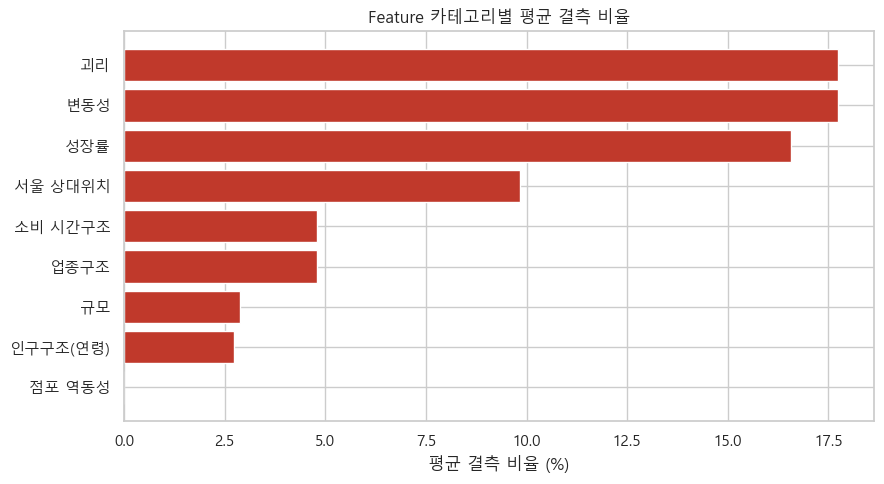

In [39]:
# (1) Feature 카테고리별 결측률
category_map = {}
for c in SCALE_COLS: category_map[c] = "규모"
for c in STORE_DYNAMICS_COLS: category_map[c] = "점포 역동성"
for c in TIME_STRUCTURE_COLS: category_map[c] = "소비 시간구조"
for c in AGE_STRUCTURE_COLS: category_map[c] = "인구구조(연령)"
for c in INDUSTRY_COLS: category_map[c] = "업종구조"
for c in GROWTH_COLS: category_map[c] = "성장률"
for c in VOLATILITY_COLS: category_map[c] = "변동성"
for c in DECOUPLING_COLS: category_map[c] = "괴리"
for c in PERCENTILE_COLS: category_map[c] = "서울 상대위치"

na_by_feature = features[FEATURE_COLS].isna().mean() * 100
na_by_category = na_by_feature.groupby(category_map).mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(na_by_category.index[::-1], na_by_category.values[::-1], color=HWANGHAK_COLOR)
ax.set_xlabel("평균 결측 비율 (%)")
ax.set_title("Feature 카테고리별 평균 결측 비율")
plt.tight_layout()
plt.show()

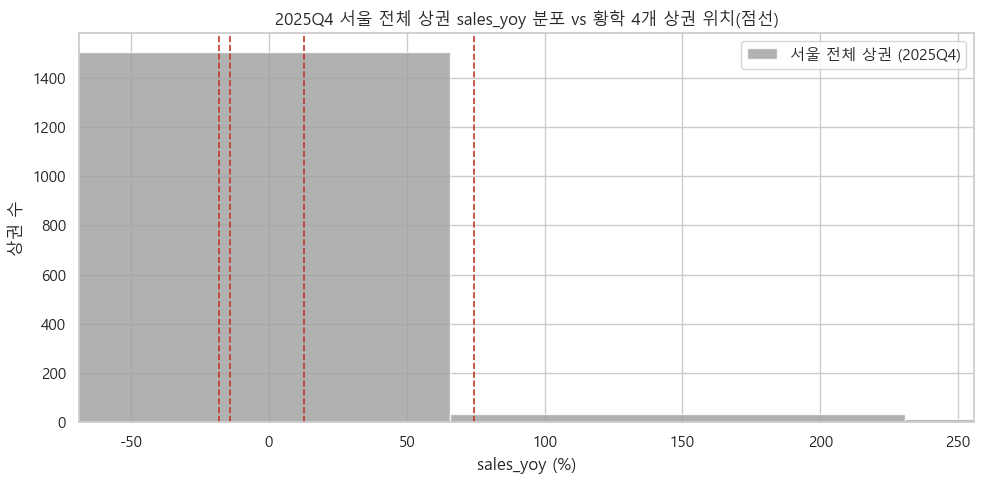

In [40]:
# (2) 핵심 성장률 feature(sales_yoy)의 최신 분기 서울 전체 분포 + 황학 4개 상권 위치
# 서로 다른 시점을 비교하지 않도록, 서울 전체 분포도 황학동과 동일한 LATEST_QUARTER로 한정한다.
# (수정 전: 전체 기간의 서울 상권 분포와 최신 분기 황학동을 비교하고 있었음 -> 동일 시점 비교로 변경)
_dist = features.loc[features["기준_년분기_코드"] == LATEST_QUARTER, "sales_yoy"].dropna()
_hw_latest_yoy = hwanghak_features.loc[hwanghak_features["기준_년분기_코드"] == LATEST_QUARTER, ["상권_코드_명", "sales_yoy"]].dropna()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(_dist, bins=40, color=SEOUL_COLOR, alpha=0.8, label=f"서울 전체 상권 ({QUARTER_LABEL_MAP[LATEST_QUARTER]})")
for _, row in _hw_latest_yoy.iterrows():
    ax.axvline(row["sales_yoy"], color=HWANGHAK_COLOR, linestyle="--", linewidth=1.2)
ax.set_xlim(_dist.quantile(0.01), _dist.quantile(0.99))
ax.set_xlabel("sales_yoy (%)")
ax.set_ylabel("상권 수")
ax.set_title(f"{QUARTER_LABEL_MAP[LATEST_QUARTER]} 서울 전체 상권 sales_yoy 분포 vs 황학 4개 상권 위치(점선)")
ax.legend()
plt.tight_layout()
plt.show()


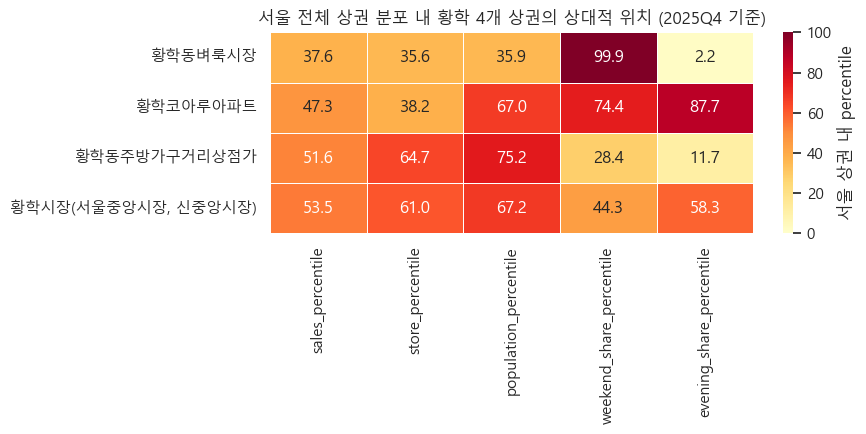

In [41]:
# (3) 황학 4개 상권의 주요 percentile 비교 (최근 분기)
percentile_heatmap_cols = ["sales_percentile", "store_percentile", "population_percentile",
                           "weekend_share_percentile", "evening_share_percentile"]
percentile_heatmap_df = (
    hwanghak_features[hwanghak_features["기준_년분기_코드"] == LATEST_QUARTER]
    .set_index("상권_코드_명")[percentile_heatmap_cols]
)

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.heatmap(percentile_heatmap_df, annot=True, fmt=".1f", cmap="YlOrRd", vmin=0, vmax=100,
            cbar_kws={"label": "서울 상권 내 percentile"}, linewidths=0.5, ax=ax)
ax.set_title(f"서울 전체 상권 분포 내 황학 4개 상권의 상대적 위치 ({QUARTER_LABEL_MAP[LATEST_QUARTER]} 기준)")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

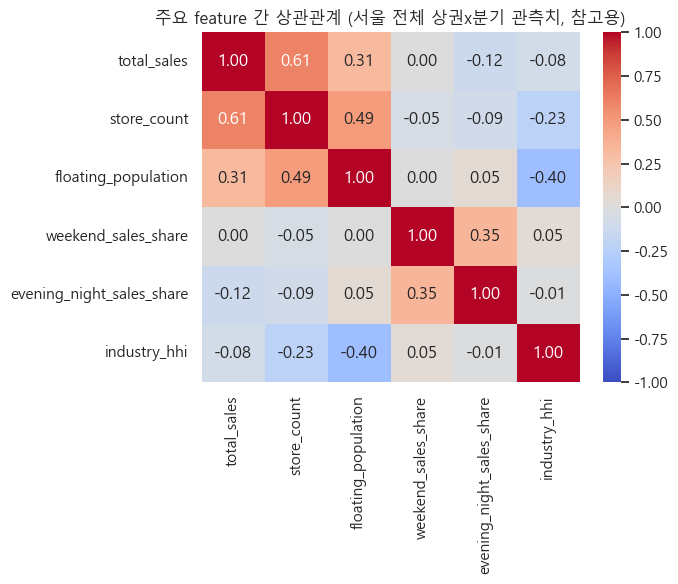

주의: 상관계수는 참고용 기술통계이며 인과관계를 의미하지 않는다.


In [42]:
# (4) 주요 변수 간 correlation heatmap (선택 변수, 전체 기간 상권x분기 관측치 기준)
CORR_COLS = ["total_sales", "store_count", "floating_population", "weekend_sales_share",
             "evening_night_sales_share", "industry_hhi"]
corr_df = features[CORR_COLS].dropna().corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("주요 feature 간 상관관계 (서울 전체 상권x분기 관측치, 참고용)")
plt.tight_layout()
plt.show()
print("주의: 상관계수는 참고용 기술통계이며 인과관계를 의미하지 않는다.")

## 23. 최종 저장

`data/processed/sales.csv`, `stores.csv`, `population.csv`는 절대 덮어쓰지 않는다. Feature Table과 Feature Dictionary를 각각 새 파일로 저장한다.

In [43]:
features.to_csv(FEATURES_OUT_PATH, encoding="utf-8-sig", index=False)
feature_dictionary.to_csv(DICTIONARY_OUT_PATH, encoding="utf-8-sig", index=False)

print("저장 완료:")
print(" -", FEATURES_OUT_PATH, f"({features.shape[0]}행 x {features.shape[1]}열)")
print(" -", DICTIONARY_OUT_PATH, f"({feature_dictionary.shape[0]}행 x {feature_dictionary.shape[1]}열)")

저장 완료:
 - ..\data\processed\commercial_features.csv (33000행 x 81열)
 - ..\data\processed\feature_dictionary.csv (75행 x 5열)


## 24. 저장 후 무결성 검증

`02_preprocessing.ipynb`와 동일한 방식으로, 저장한 파일을 다시 읽어 shape/컬럼명·순서/핵심 key dtype/중복/상권 수/분기 수/NaN 개수가 저장 전과 동일한지 확인한다.

In [44]:
reloaded = pd.read_csv(FEATURES_OUT_PATH, encoding="utf-8-sig")

print("원본 shape:", features.shape, "/ 재로드 shape:", reloaded.shape)
assert features.shape == reloaded.shape, "저장 전후 shape가 다릅니다."

assert features.columns.tolist() == reloaded.columns.tolist(), "저장 전후 컬럼명/순서가 다릅니다."
print("컬럼명/순서 일치 확인")

print("기준_년분기_코드 dtype: 원본=", features["기준_년분기_코드"].dtype, "/ 재로드=", reloaded["기준_년분기_코드"].dtype)
print("상권_코드 dtype: 원본=", features["상권_코드"].dtype, "/ 재로드=", reloaded["상권_코드"].dtype)
assert features["기준_년분기_코드"].dtype == reloaded["기준_년분기_코드"].dtype
assert features["상권_코드"].dtype == reloaded["상권_코드"].dtype

assert int(reloaded.duplicated(subset=["기준_년분기_코드", "상권_코드"]).sum()) == 0, "재로드 데이터에 key 중복이 있습니다."
print("key 중복 없음 확인")

assert features["상권_코드"].nunique() == reloaded["상권_코드"].nunique()
assert features["기준_년분기_코드"].nunique() == reloaded["기준_년분기_코드"].nunique()
print("상권 수:", reloaded["상권_코드"].nunique(), "/ 분기 수:", reloaded["기준_년분기_코드"].nunique())

_na_before = features[FEATURE_COLS].isna().sum().sum()
_na_after = reloaded[FEATURE_COLS].isna().sum().sum()
print("핵심 feature 전체 NaN 개수: 저장 전=", int(_na_before), "/ 재로드 후=", int(_na_after))
assert int(_na_before) == int(_na_after), "저장 전후 NaN 개수가 다릅니다."

reloaded_dict = pd.read_csv(DICTIONARY_OUT_PATH, encoding="utf-8-sig")
assert reloaded_dict.shape == feature_dictionary.shape, "feature_dictionary 저장 전후 shape가 다릅니다."
print("\nfeature_dictionary 재로드 shape 일치 확인:", reloaded_dict.shape)

print("\n저장 후 무결성 검증 통과 (shape / 컬럼명·순서 / key dtype / 중복 / 상권수·분기수 / NaN개수 모두 일치)")

원본 shape: (33000, 81) / 재로드 shape: (33000, 81)
컬럼명/순서 일치 확인
기준_년분기_코드 dtype: 원본= int64 / 재로드= int64
상권_코드 dtype: 원본= int64 / 재로드= int64
key 중복 없음 확인
상권 수: 1650 / 분기 수: 20
핵심 feature 전체 NaN 개수: 저장 전= 190264 / 재로드 후= 190264

feature_dictionary 재로드 shape 일치 확인: (75, 5)

저장 후 무결성 검증 통과 (shape / 컬럼명·순서 / key dtype / 중복 / 상권수·분기수 / NaN개수 모두 일치)


In [45]:
print("=== 04_feature_engineering.ipynb 실행 결과 요약 ===")
print("최종 Feature Table shape:", features.shape)
print("생성한 feature 개수(식별자/coverage 제외):", len(FEATURE_COLS))
print("고유 상권 수:", features["상권_코드"].nunique())
print("분석 기간:", QUARTER_LABELS[0], "~", QUARTER_LABELS[-1], f"({features['기준_년분기_코드'].nunique()}개 분기)")
print("has_sales=False 행 수:", int((~features['has_sales']).sum()))
print("has_population=False 행 수:", int((~features['has_population']).sum()))
print("complete_case=True 비율(%):", round(features['complete_case'].mean() * 100, 2))
print("황학 4개 상권 포함 및 20개 분기 완전성:", (quarters_per_area == 20).all())
print("저장 경로:", FEATURES_OUT_PATH, "/", DICTIONARY_OUT_PATH)

=== 04_feature_engineering.ipynb 실행 결과 요약 ===
최종 Feature Table shape: (33000, 81)
생성한 feature 개수(식별자/coverage 제외): 71
고유 상권 수: 1650
분석 기간: 2021Q1 ~ 2025Q4 (20개 분기)
has_sales=False 행 수: 1585
has_population=False 행 수: 16
complete_case=True 비율(%): 95.15
황학 4개 상권 포함 및 20개 분기 완전성: True
저장 경로: ..\data\processed\commercial_features.csv / ..\data\processed\feature_dictionary.csv


## 결과 요약

### 생성된 Feature Category

- **규모**: `total_sales`, `total_transactions`, `avg_transaction_value`, `store_count`, `floating_population`
- **점포 역동성**: 개업/폐업/프랜차이즈 점포 수, `net_store_change`, `franchise_share`, `opening_intensity`, `closing_intensity`
- **소비 시간구조**: 주중/주말 비중, 심야/오전/낮/저녁·야간 매출 비중
- **인구구조(연령)**: 매출·유동인구 연령 구성비(10~60대 이상, 2030 composite), 연령 구성 괴리(`age_2030_gap`, `age_60plus_gap`)
- **업종구조**: 가구/한식음식점/전자상거래업 비중, `top1`/`top3_industry_share`, `industry_hhi`, `active_industry_count`
- **성장률**: QoQ/YoY(매출·거래건수·점포수·유동인구), log growth(매출·유동인구·점포수)
- **변동성**: 매출/유동인구/점포수의 4분기 trailing 평균·표준편차·변동계수
- **괴리(decoupling)**: 매출-유동인구/매출-점포수의 YoY·log growth·percentile 차이
- **서울 상대위치**: 매출/점포수/유동인구 수준 percentile, YoY·주말비중·저녁야간비중 percentile

### 데이터 범위

- 서울 전체 상권 대상 (황학동 4개 상권으로 필터링하지 않음)
- 2021Q1~2025Q4 (20개 분기), grain = `기준_년분기_코드 x 상권_코드` (33,000행, 1,650개 상권)
- 황학동 4개 상권(3110055, 3110057, 3130054, 3130055) 모두 20개 분기 전체 포함 확인

### 주의사항

- 초기 분기의 lag/QoQ(2021Q1)/YoY(2021년 4개 분기)/rolling(2021Q1~Q3) feature는 구조적으로 `NaN`이다(미래 정보를 사용하지 않았다는 근거이기도 하다).
- 데이터가 없는 상권-분기는 `fillna(0)`으로 대체하지 않고 `NaN`으로 유지했으며, 대신 `has_sales`/`has_population`/`complete_case` coverage flag로 원인을 구분할 수 있게 했다.
- 연령대별/성별 세부 항목 합계와 총합(`당월_매출_금액`, `총_유동인구_수`) 사이에는 `02_preprocessing.ipynb`에서 확인된 집계 기준 차이가 존재할 수 있어, 연령 구성비는 항상 세부 항목 내부 합을 분모로 사용했다.
- 이 Feature Table의 값들은 어디까지나 **관측 가능한 지표**이며, 쇠퇴/회복/구조전환 등의 판정값이 아니다. `opening_intensity`/`closing_intensity`도 서울시 공식 개업률/폐업률이 아니라 이 프로젝트에서 정의한 지표임을 다시 한 번 밝힌다.

### 다음 단계

다음 단계에서는 이 Feature Table(`data/processed/commercial_features.csv`)을 이용하여 `05_commercial_signal.ipynb`에서

- 서울 전체 상권의 변화 분포 분석
- 상권별 이상/변화 신호 정의
- 황학동 4개 상권 진단
- 쇠퇴/회복/구조전환 패턴을 어떤 기준으로 정의할지 검토

를 진행한다. 이번 노트북에서는 그 판정 기준(예: `decline_score` 등 종합 점수)을 미리 구현하지 않았다.